# Deep Learning SmolVLM VQA Project

## Running Instructions

Remember to create a Virtual Environment and pip install from requirements.txt

#### Windows Installation Commands
```
py -m venv venv
venv/Scripts/activate.bat
pip install -r requirements.txt
```

Note: A NVIDIA A100 GPU (Standard/ No High-RAM, 40GB VRAM) \[Worst Case: Less Than 20GB of VRAM was used \] on Google Colab was used for 4x4 Batch Size training (Batch Size: 16). For GPUs with less VRAM (Recommended 16GB), adjust the batch size accordingly (an alternate 16 Batch Size (2x8) code has been provided/commented out inside of the training code of the Ablation)

Assuming you have the following relevant files / folders (with the files) in your root directory, you can skip to the Training & Inference Section (All Ablations besides the final/winning one have been commented out):

- combined_train_folds_full_multilabel.csv
- images\images\train_val_refined
- test_original.csv

**Note**: When it comes to adjusting the image path of the combined_train_folds/test_x csv files (Due to having a different BASE DIRECTORY), you can change the Base Directory inside of the CONSTANTS definition cell and uncomment out the setup code towards the beginning of the Training & Inference section.

You can also skip to the Inference section of the Final Ablation (Ablation #5.3.4) if the following adapter folder exists in your root directory:

- smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora_higher_dropout

It can be downloaded here, if not already present:

Otherwise, you can acquire the other folders for the other Ablations by uncommenting out the code inside of the Data Analysis/Engineering and/or the beginning of the Training & Inference section.

## Data Analysis/Engineering

In [ ]:
# !pip install iterative-stratification transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow pandas torch tqdm google-generativeai seaborn matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Imports & Configuration

import random
import numpy as np
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

# # Colab
# INPUT_BASE_DIR = Path("/content/drive/MyDrive/pixels-to-predictions")
# BASE_DIR = Path("/content/drive/MyDrive/pixels-to-predictions")

# # Kaggle
# INPUT_BASE_DIR = Path("/kaggle/input/competitions/pixels-to-predictions")
# BASE_DIR = Path("/kaggle/working")

# Local
INPUT_BASE_DIR = Path("./")
BASE_DIR = Path("./")

TRAIN_CSV = INPUT_BASE_DIR / "train.csv"
VAL_CSV = INPUT_BASE_DIR / "val.csv"
TEST_CSV = INPUT_BASE_DIR / "test.csv"

IMAGE_TRAIN_DIR =  INPUT_BASE_DIR / "images/images/train/"
IMAGE_VAL_DIR =  INPUT_BASE_DIR / "images/images/val/"
IMAGE_TEST_DIR =  INPUT_BASE_DIR / "images/images/test/"
IMAGE_TRAIN_VAL_DIR = BASE_DIR / "images/images/train_val/"

IMG_SIZE = 512

REFINED_IMAGE_TRAIN_DIR =  BASE_DIR / "images/images/train_refined/"
REFINED_IMAGE_VAL_DIR =  BASE_DIR / "images/images/val_refined/"
REFINED_IMAGE_TEST_DIR =  BASE_DIR / "images/images/test_refined/"
REFINED_IMAGE_TRAIN_VAL_DIR = BASE_DIR / "images/images/train_val_refined/"

TEST_REFINED_CSV = BASE_DIR / "test_refined.csv"
TEST_ORIGINAL_CSV = BASE_DIR / "test_original.csv"

IMG_SIZE_224 = 224

REFINED_IMAGE_TRAIN_224_DIR =  BASE_DIR / "images/images/train_refined_224/"
REFINED_IMAGE_VAL_224_DIR =  BASE_DIR / "images/images/val_refined_224/"
REFINED_IMAGE_TEST_224_DIR =  BASE_DIR / "images/images/test_refined_224/"
REFINED_IMAGE_TRAIN_VAL_224_DIR = BASE_DIR / "images/images/train_val_refined_224/"

KFOLD_CSV = BASE_DIR / "combined_train_folds_full_multilabel.csv"
MINI_KFOLD_CSV = BASE_DIR / "combined_train_folds_mini_multilabel.csv"

KFOLD_512_CSV = BASE_DIR / "combined_train_folds_full_multilabel_512.csv"
MINI_KFOLD_512_CSV = BASE_DIR / "combined_train_folds_mini_multilabel_512.csv"

KFOLD_224_CSV = BASE_DIR / "combined_train_folds_full_multilabel_224.csv"
MINI_KFOLD_224_CSV = BASE_DIR / "combined_train_folds_mini_multilabel_224.csv"

# Synthesized K_FOLD for Missing 701 Solutions
KFOLD_SYNTHESIZED_CSV = BASE_DIR / "combined_train_folds_full_multilabel_synthesized.csv"
KFOLD_SYNTHESIZED_CLEAN_CSV = BASE_DIR / "combined_train_folds_full_multilabel_cleaned.csv"
KFOLD_SYNTHESIZED_FINAL_CSV = BASE_DIR / "combined_train_folds_full_multilabel_final.csv"


### Feature Analysis/Engineering


========== Distribution for: answer ==========
        Frequency  Percentage (%)
answer                           
0            1124           36.15
1            1028           33.07
2             737           23.71
3             204            6.56
4              16            0.51


C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


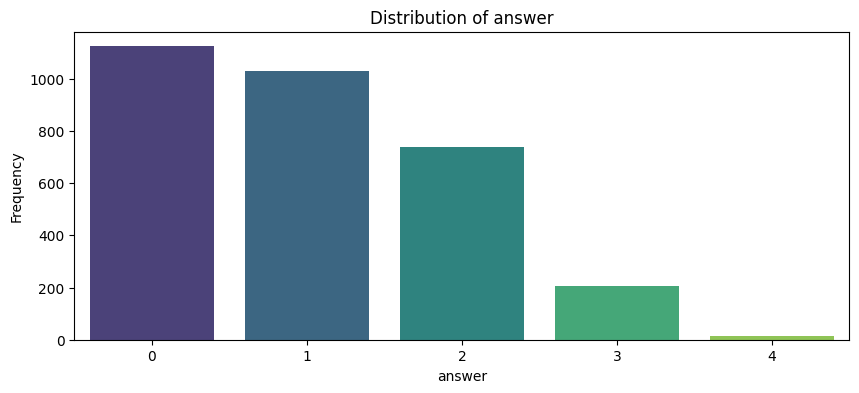


========== Distribution for: subject ==========
                  Frequency  Percentage (%)
subject                                    
natural science        2264           72.82
social science          768           24.70
language science         77            2.48


C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


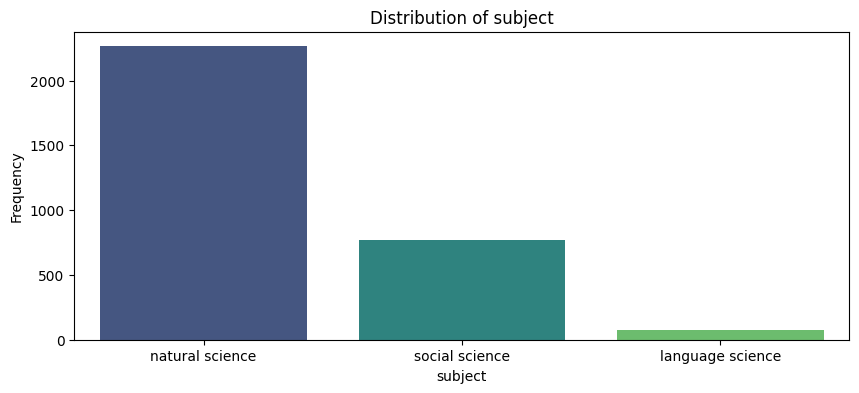

C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')



========== Distribution for: category ==========
                                     Frequency  Percentage (%)
category                                                      
Designing experiments                      222            7.14
Solutions                                  222            7.14
Ecosystems                                 195            6.27
Maps                                       190            6.11
Velocity, acceleration, and forces         186            5.98
Magnets                                    179            5.76
Engineering practices                      174            5.60
Particle motion and energy                 169            5.44
Basic economic principles                  163            5.24
Geography                                  160            5.15
Genes to traits                            117            3.76
Classification and scientific names        114            3.67
Adaptations                                101            3.25
Scien

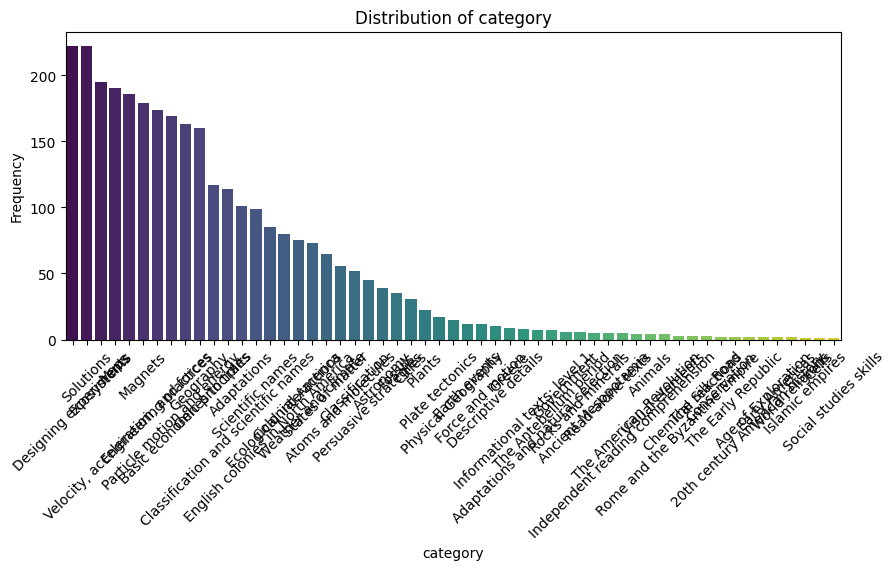


========== Distribution for: grade ==========
         Frequency  Percentage (%)
grade                             
grade8         685           22.03
grade6         611           19.65
grade7         545           17.53
grade4         484           15.57
grade5         354           11.39
grade3         289            9.30
grade2         115            3.70
grade12         21            0.68
grade1           5            0.16


C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


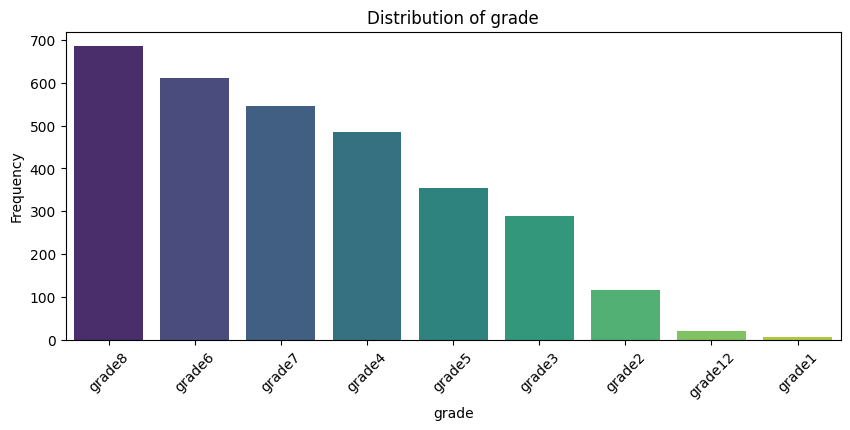


========== Distribution for: num_choices ==========
             Frequency  Percentage (%)
num_choices                           
3                 1552           49.92
4                  783           25.18
2                  664           21.36
5                  110            3.54


C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


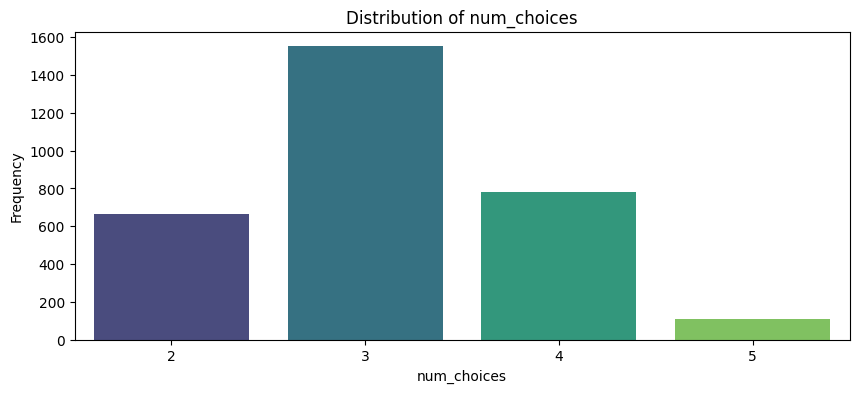


========== Distribution for: skill ==========
                                                    Frequency  Percentage (%)
skill                                                                        
Compare magnitudes of magnetic forces                     251            8.07
Read a map: cardinal directions                           248            7.98
Use scientific names to classify organisms                213            6.85
Compare concentrations of solutions                       192            6.18
Evaluate tests of engineering-design solutions            171            5.50
...                                                       ...             ...
Alexander the Great                                         1            0.03
Describe and construct flowering plant life cycles          1            0.03
The Revolutionary War: struggle for independence            1            0.03
How does particle motion affect gas pressure?               1            0.03
Genes, proteins, 

C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


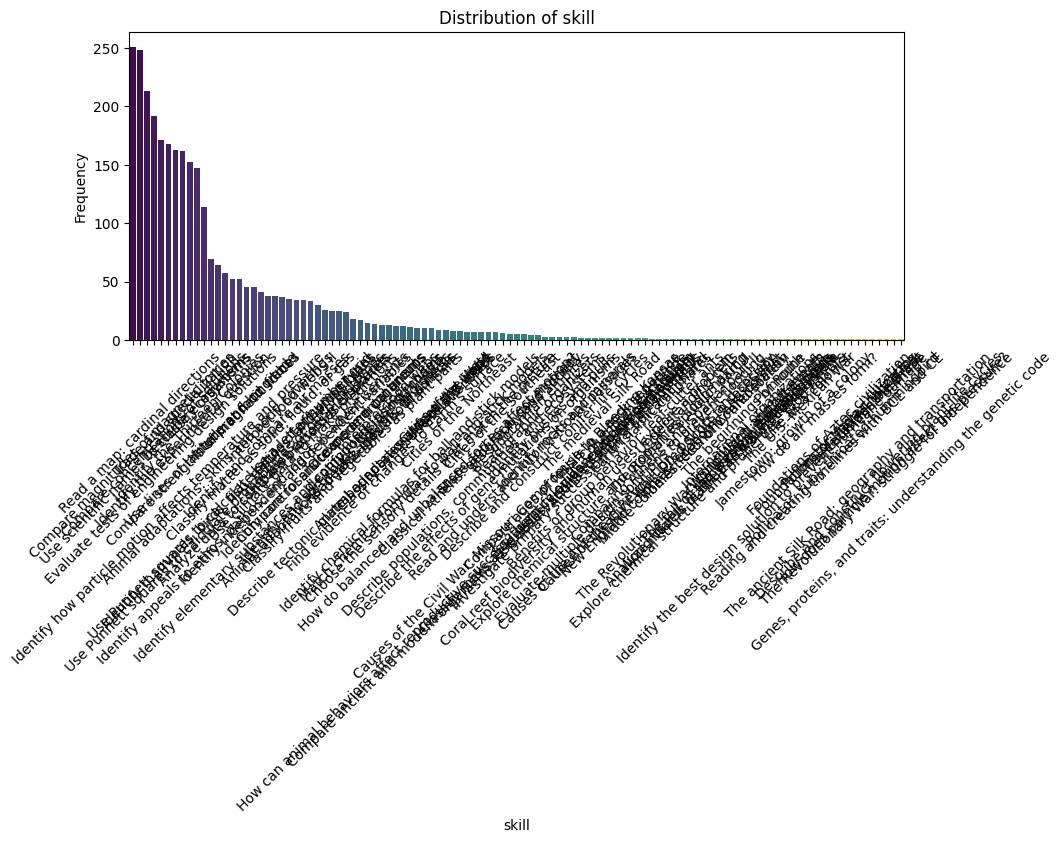


========== Distribution for: topic ==========
                                   Frequency  Percentage (%)
topic                                                       
biology                                  779           25.06
physics                                  611           19.65
geography                                396           12.74
science-and-engineering-practices        393           12.64
chemistry                                281            9.04
earth-science                            182            5.85
us-history                               173            5.56
economics                                163            5.24
writing-strategies                        59            1.90
world-history                             30            0.96
literacy-in-science                       18            0.58
reading-comprehension                     18            0.58
civics                                     5            0.16
global-studies                        

C:\Users\Josue\AppData\Local\Temp\ipykernel_3632\3067765602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')


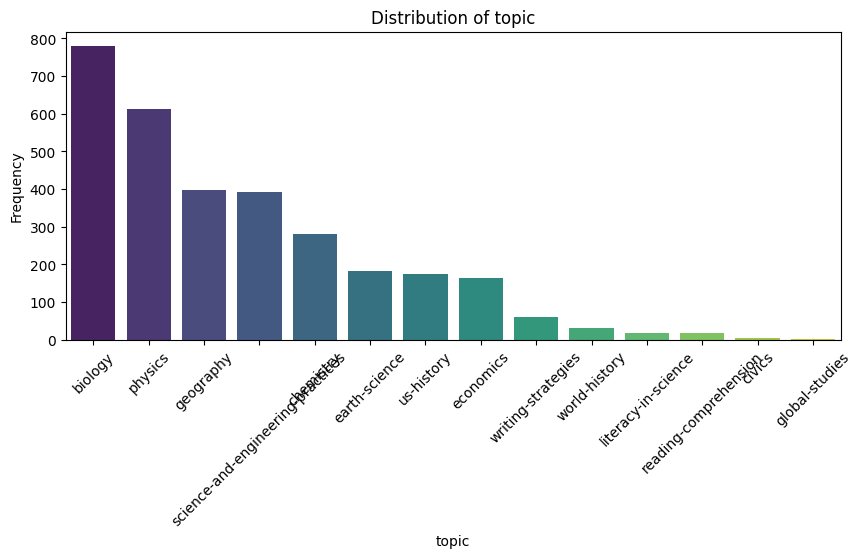

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load your CSV data
# df = pd.read_csv(TRAIN_CSV)

# def analyze_distributions(df, columns):
#     for col in columns:
#         if col not in df.columns:
#             continue

#         print(f"\n{'='*10} Distribution for: {col} {'='*10}")

#         # Calculate Frequency and Percentage
#         freq = df[col].value_counts()
#         perc = df[col].value_counts(normalize=True) * 100

#         # Create a summary table
#         summary = pd.DataFrame({
#             'Frequency': freq,
#             'Percentage (%)': perc.round(2)
#         })
#         print(summary)

#         # Plot Distribution
#         plt.figure(figsize=(10, 4))
#         sns.barplot(x=summary.index, y='Frequency', data=summary, palette='viridis')
#         plt.title(f'Distribution of {col}')
#         plt.xticks(rotation=45 if len(summary) > 5 else 0)
#         plt.show()

# # Columns most relevant to scientific reasoning and stratification
# cols_to_check = ['answer', 'subject', 'category', 'grade', 'num_choices', 'skill', 'topic']

# analyze_distributions(df, cols_to_check)

In [ ]:
# import pandas as pd
# from pathlib import Path
# from sklearn.model_selection import train_test_split
# from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# # 1. Load and Merge Data
# train_df = pd.read_csv(TRAIN_CSV)
# val_df = pd.read_csv(VAL_CSV)
# combined_df = pd.concat([train_df, val_df], ignore_index=True)

# def create_multilabel_folds(df, num_folds=5, stratify_cols=['answer', 'topic'], output_filename='folds.csv'):
#     """
#     Applies Multilabel Stratified K-Fold to balance multiple independent columns simultaneously.
#     """
#     print(f"Creating {num_folds} folds for {len(df)} rows, stratifying by: {stratify_cols}")

#     # Create a one-hot encoded matrix for the stratifier
#     # This turns 'answer' and 'topic' into binary columns that the algorithm balances
#     y_stratify = pd.get_dummies(df[stratify_cols])

#     mskf = MultilabelStratifiedKFold(n_splits=num_folds, shuffle=True, random_state=SEED)
#     df = df.copy()
#     df['fold'] = -1

#     for fold, (train_idx, val_idx) in enumerate(mskf.split(df, y_stratify)):
#         df.loc[val_idx, 'fold'] = fold

#     df.to_csv(output_filename, index=False)
#     print(f" ~ Saved {output_filename}\n")
#     return df

In [ ]:
# # ---------------------------------------------------------
# # ACTION 1: Create the FULL Multilabel Stratified Dataset
# # ---------------------------------------------------------
# full_folds_df = create_multilabel_folds(
#     combined_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=KFOLD_CSV
# )

# # ---------------------------------------------------------
# # ACTION 2: Create the MINI Multilabel Stratified Dataset
# # ---------------------------------------------------------
# # First, safely extract a 20% chunk. We stratify this initial extraction
# # by 'answer' to ensure the subset perfectly mirrors the target distribution.
# mini_df, _ = train_test_split(
#     combined_df,
#     train_size=0.20,
#     stratify=combined_df['answer'],
#     random_state=SEED
# )
# mini_df = mini_df.reset_index(drop=True)

# # Now, apply the 5-Fold Multilabel Stratification to the mini subset
# mini_folds_df = create_multilabel_folds(
#     mini_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=MINI_KFOLD_CSV
# )

Creating 5 folds for 4157 rows, stratifying by: ['answer', 'topic']
 ~ Saved /content/drive/MyDrive/pixels-to-predictions/combined_train_folds_full_multilabel.csv

Creating 5 folds for 831 rows, stratifying by: ['answer', 'topic']
 ~ Saved /content/drive/MyDrive/pixels-to-predictions/combined_train_folds_mini_multilabel.csv



In [ ]:
# # ---------------------------------------------------------
# # ACTION 1: Create the FULL Multilabel Stratified Dataset
# # ---------------------------------------------------------
# full_folds_df = create_multilabel_folds(
#     combined_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=KFOLD_512_CSV
# )

# # ---------------------------------------------------------
# # ACTION 2: Create the MINI Multilabel Stratified Dataset
# # ---------------------------------------------------------
# # First, safely extract a 20% chunk. We stratify this initial extraction
# # by 'answer' to ensure the subset perfectly mirrors the target distribution.
# mini_df, _ = train_test_split(
#     combined_df,
#     train_size=0.20,
#     stratify=combined_df['answer'],
#     random_state=SEED
# )
# mini_df = mini_df.reset_index(drop=True)

# # Now, apply the 5-Fold Multilabel Stratification to the mini subset
# mini_folds_df = create_multilabel_folds(
#     mini_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=MINI_KFOLD_512_CSV
# )

Creating 5 folds for 4157 rows, stratifying by: ['answer', 'topic']
 ~ Saved /kaggle/working/combined_train_folds_full_multilabel_512.csv

Creating 5 folds for 831 rows, stratifying by: ['answer', 'topic']
 ~ Saved /kaggle/working/combined_train_folds_mini_multilabel_512.csv



In [ ]:
# import pandas as pd

# # Load the generated folds dataset
# # Change this to 'combined_train_folds_full_multilabel.csv' when testing the full set
# df = pd.read_csv(KFOLD_CSV)

# print("=== Verification of Fold Statistics ===")
# print(f"Total rows in dataset: {len(df)}\n")

# print("--- 1. Number of Examples per Fold ---")
# print(df['fold'].value_counts().sort_index())

# print("\n--- 2. Answer Distribution per Fold (Percentages) ---")
# # crosstab calculates the frequency, normalize='index' turns it into row percentages
# answer_dist = pd.crosstab(df['fold'], df['answer'], normalize='index') * 100
# print(answer_dist.round(2))

# print("\n--- 3. Topic Distribution per Fold (Percentages) ---")
# topic_dist = pd.crosstab(df['fold'], df['topic'], normalize='index') * 100

# # We transpose (.T) it so topics are rows and folds are columns for easier reading
# print(topic_dist.T.round(2))

=== Verification of Fold Statistics ===
Total rows in dataset: 4157

--- 1. Number of Examples per Fold ---
fold
0    832
1    832
2    831
3    831
4    831
Name: count, dtype: int64

--- 2. Answer Distribution per Fold (Percentages) ---
answer      0      1      2     3     4
fold                                   
0       35.46  34.86  23.32  6.01  0.36
1       35.46  34.13  24.04  5.53  0.84
2       35.38  33.57  23.95  6.86  0.24
3       35.38  33.33  23.95  6.74  0.60
4       35.26  32.49  23.10  8.42  0.72

--- 3. Topic Distribution per Fold (Percentages) ---
fold                                   0      1      2      3      4
topic                                                               
biology                            25.36  25.36  25.27  25.27  25.27
chemistry                           9.01   9.01   8.90   8.90   8.90
civics                              0.24   0.12   0.12   0.12   0.12
earth-science                       6.37   6.25   6.38   6.26   6.38
economics    

In [ ]:
# import pandas as pd

# # Load the generated Mini folds dataset
# # Change this to 'combined_train_folds_mini_multilabel.csv' when testing the mini set
# df = pd.read_csv(MINI_KFOLD_CSV)

# print("=== Verification of Fold Statistics ===")
# print(f"Total rows in dataset: {len(df)}\n")

# print("--- 1. Number of Examples per Fold ---")
# print(df['fold'].value_counts().sort_index())

# print("\n--- 2. Answer Distribution per Fold (Percentages) ---")
# # crosstab calculates the frequency, normalize='index' turns it into row percentages
# answer_dist = pd.crosstab(df['fold'], df['answer'], normalize='index') * 100
# print(answer_dist.round(2))

# print("\n--- 3. Topic Distribution per Fold (Percentages) ---")
# topic_dist = pd.crosstab(df['fold'], df['topic'], normalize='index') * 100

# # We transpose (.T) it so topics are rows and folds are columns for easier reading
# print(topic_dist.T.round(2))

=== Verification of Fold Statistics ===
Total rows in dataset: 831

--- 1. Number of Examples per Fold ---
fold
0    166
1    166
2    167
3    166
4    166
Name: count, dtype: int64

--- 2. Answer Distribution per Fold (Percentages) ---
answer      0      1      2     3    4
fold                                  
0       35.54  34.34  23.49  5.42  1.2
1       34.94  34.94  23.49  5.42  1.2
2       35.93  31.14  24.55  8.38  0.0
3       35.54  33.13  23.49  7.83  0.0
4       34.94  34.94  23.49  6.63  0.0

--- 3. Topic Distribution per Fold (Percentages) ---
fold                                   0      1      2      3      4
topic                                                               
biology                            25.30  25.30  25.75  25.30  25.30
chemistry                           8.43   8.43   7.78   8.43   8.43
civics                              0.00   0.60   0.00   0.60   0.00
earth-science                       5.42   5.42   5.39   5.42   5.42
economics            

In [ ]:
# import pandas as pd
# import json
# from transformers import AutoTokenizer
# import matplotlib.pyplot as plt
# import numpy as np

# # Load the Processor
# # We only need the tokenizer component to count text tokens
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# # Load the Dataset
# # Use the mini dataset for a quick check, or the full one for exact stats
# df = pd.read_csv(KFOLD_CSV)

# # Helper to parse choices into the string format you will use
# def format_choices(choices_raw):
#     """Parses the JSON choices into a clean lettered list string."""
#     CHOICE_LETTERS = "ABCDEFGHIJ"
#     try:
#         choices_list = json.loads(choices_raw)
#     except:
#         choices_list = eval(choices_raw)
#     return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

# # Extract columns and fill NaNs
# texts = {
#     'question': df['question'].fillna("").tolist(),
#     'choices': df['choices'].apply(format_choices).tolist(),
#     'hint': df['hint'].fillna("").tolist(),
#     'lecture': df['lecture'].fillna("").tolist(),
#     'solution': df['solution'].fillna("").tolist() # Included just to see its token length!
# }

# # Tokenize and calculate statistics
# stats = []
# print("Calculating token statistics...")
# for col, txt_list in texts.items():
#     # Keep only non-empty strings so NaNs don't artificially lower the mean
#     non_empty = [t for t in txt_list if str(t).strip() != ""]
#     if not non_empty:
#         continue

#     # Tokenize the text block
#     tokens = tokenizer(non_empty, add_special_tokens=False)['input_ids']
#     lengths = [len(t) for t in tokens]

#     stats.append({
#         'Feature': col,
#         'Present Rows': len(lengths),
#         'Min Tokens': np.min(lengths),
#         'Mean Tokens': round(np.mean(lengths), 1),
#         '95th Percentile': round(np.percentile(lengths, 95), 1),
#         'Max Tokens': np.max(lengths)
#     })

# # Display the results nicely
# stats_df = pd.DataFrame(stats)
# print("\n--- Token Length Statistics (SmolVLM) ---")
# display(stats_df)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Calculating token statistics...

--- Token Length Statistics (SmolVLM) ---


,Feature,Present Rows,Min Tokens,Mean Tokens,95th Percentile,Max Tokens
0,question,4157,4,14.1,23.0,61
1,choices,4157,8,28.9,56.0,78
2,hint,3201,8,65.2,188.0,407
3,lecture,3584,27,162.9,304.0,441
4,solution,3456,5,85.6,212.0,536


### Image Analysis/Engineering

Summary: We explored Offline Image Preprocessing (Reiszing and Sharpening) at 224x224 and 512x512 resolutions. We peformed training with these offline images with both AutoProcessor Resizing and Padding set to false (do_resize=False & do_pad=False) and got reduced quality results. Our best results were yielded from using the original images and relying on the AutoProcessor's default resizing of (2048x2048) and padding to acquire better results. We also tried synthesizing solutions for the missing entries for our Chain of Thought (CoT) approach, but this architecture did not perform well solely on the Lora Attention Layers Only (not MLP layers).

We did Zero-Shot Inferencing on both 224 and 512 Images along with prompt exploration and discovered that 512 resized images performed better, but we realized we should just rely on original image sizes and AutoProcessor.

In [ ]:
# import os
# from PIL import Image
# import numpy as np

# def analyze_image_directory(directory):
#     # Check if the path exists to avoid errors
#     if not os.path.exists(directory):
#         return f"Error: Directory '{directory}' not found. Check the path in the sidebar."

#     widths, heights, file_sizes = [], [], []
#     valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

#     # Get image files
#     image_files = [f for f in os.listdir(directory) if f.lower().endswith(valid_extensions)]

#     if not image_files:
#         return "No image files found in this folder."

#     print(f"Processing {len(image_files)} images...")

#     for filename in image_files:
#         filepath = os.path.join(directory, filename)
#         try:
#             with Image.open(filepath) as img:
#                 w, h = img.size
#                 widths.append(w)
#                 heights.append(h)
#             file_sizes.append(os.path.getsize(filepath) / 1024)
#         except Exception:
#             continue # Skip corrupted images

#     # Final Summary
#     return (
#         f"--- Dataset Summary ---\n"
#         f"Total Images: {len(widths)}\n"
#         f"Average Resolution: {int(np.mean(widths))} x {int(np.mean(heights))}\n"
#         f"Median Resolution: {int(np.median(widths))} x {int(np.median(heights))}\n"
#         f"Max Resolution: {max(widths)} x {max(heights)}\n"
#         f"Average File Size: {np.mean(file_sizes):.2f} KB\n"
#     )


In [ ]:
# # Print the analysis for each directory

# print(analyze_image_directory(IMAGE_TRAIN_DIR))
# print(analyze_image_directory(IMAGE_VAL_DIR))
# print(analyze_image_directory(IMAGE_TEST_DIR))


Processing 3109 images...
--- Dataset Summary ---
Total Images: 3109
Average Resolution: 445 x 284
Median Resolution: 391 x 239
Max Resolution: 760 x 595
Average File Size: 71.50 KB

Processing 1048 images...
--- Dataset Summary ---
Total Images: 1048
Average Resolution: 446 x 279
Median Resolution: 426 x 239
Max Resolution: 760 x 595
Average File Size: 68.95 KB

Processing 1008 images...
--- Dataset Summary ---
Total Images: 1008
Average Resolution: 438 x 281
Median Resolution: 426 x 237
Max Resolution: 760 x 595
Average File Size: 72.22 KB



In [ ]:
# import os
# import numpy as np
# from PIL import Image
# from scipy.signal import convolve2d

# def get_sharpness(img_array):
#     # Laplacian kernel to detect edges
#     kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
#     # Variance of the convolution measures sharpness
#     return convolve2d(img_array, kernel, mode='valid').var()

# def check_blur_impact(directory, target_size=512, sample_size=100):
#     files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:sample_size]
#     sharpness_loss = []

#     for f in files:
#         with Image.open(os.path.join(directory, f)).convert('L') as img:
#             # Score original
#             orig_score = get_sharpness(np.array(img))

#             # Simulate the model's resize (LANCZOS is best for text)
#             resized = img.resize((target_size, target_size), resample=Image.LANCZOS)
#             resized_score = get_sharpness(np.array(resized))

#             # Calculate % loss of edge detail
#             loss = (orig_score - resized_score) / orig_score * 100
#             sharpness_loss.append(max(0, loss))

#     print(f"--- Blur Impact Analysis (Sample: {len(files)}) ---")
#     print(f"Avg Sharpness Loss: {np.mean(sharpness_loss):.2f}%")
#     print(f"Max Sharpness Loss: {np.max(sharpness_loss):.2f}%")
#     print("\nTip: If loss > 15%, apply RandomSharpness in your training pipeline.")

In [ ]:
# check_blur_impact(IMAGE_TRAIN_DIR, target_size=IMG_SIZE)

--- Blur Impact Analysis (Sample: 100) ---
Avg Sharpness Loss: 70.32%
Max Sharpness Loss: 98.77%

Tip: If loss > 15%, apply RandomSharpness in your training pipeline.


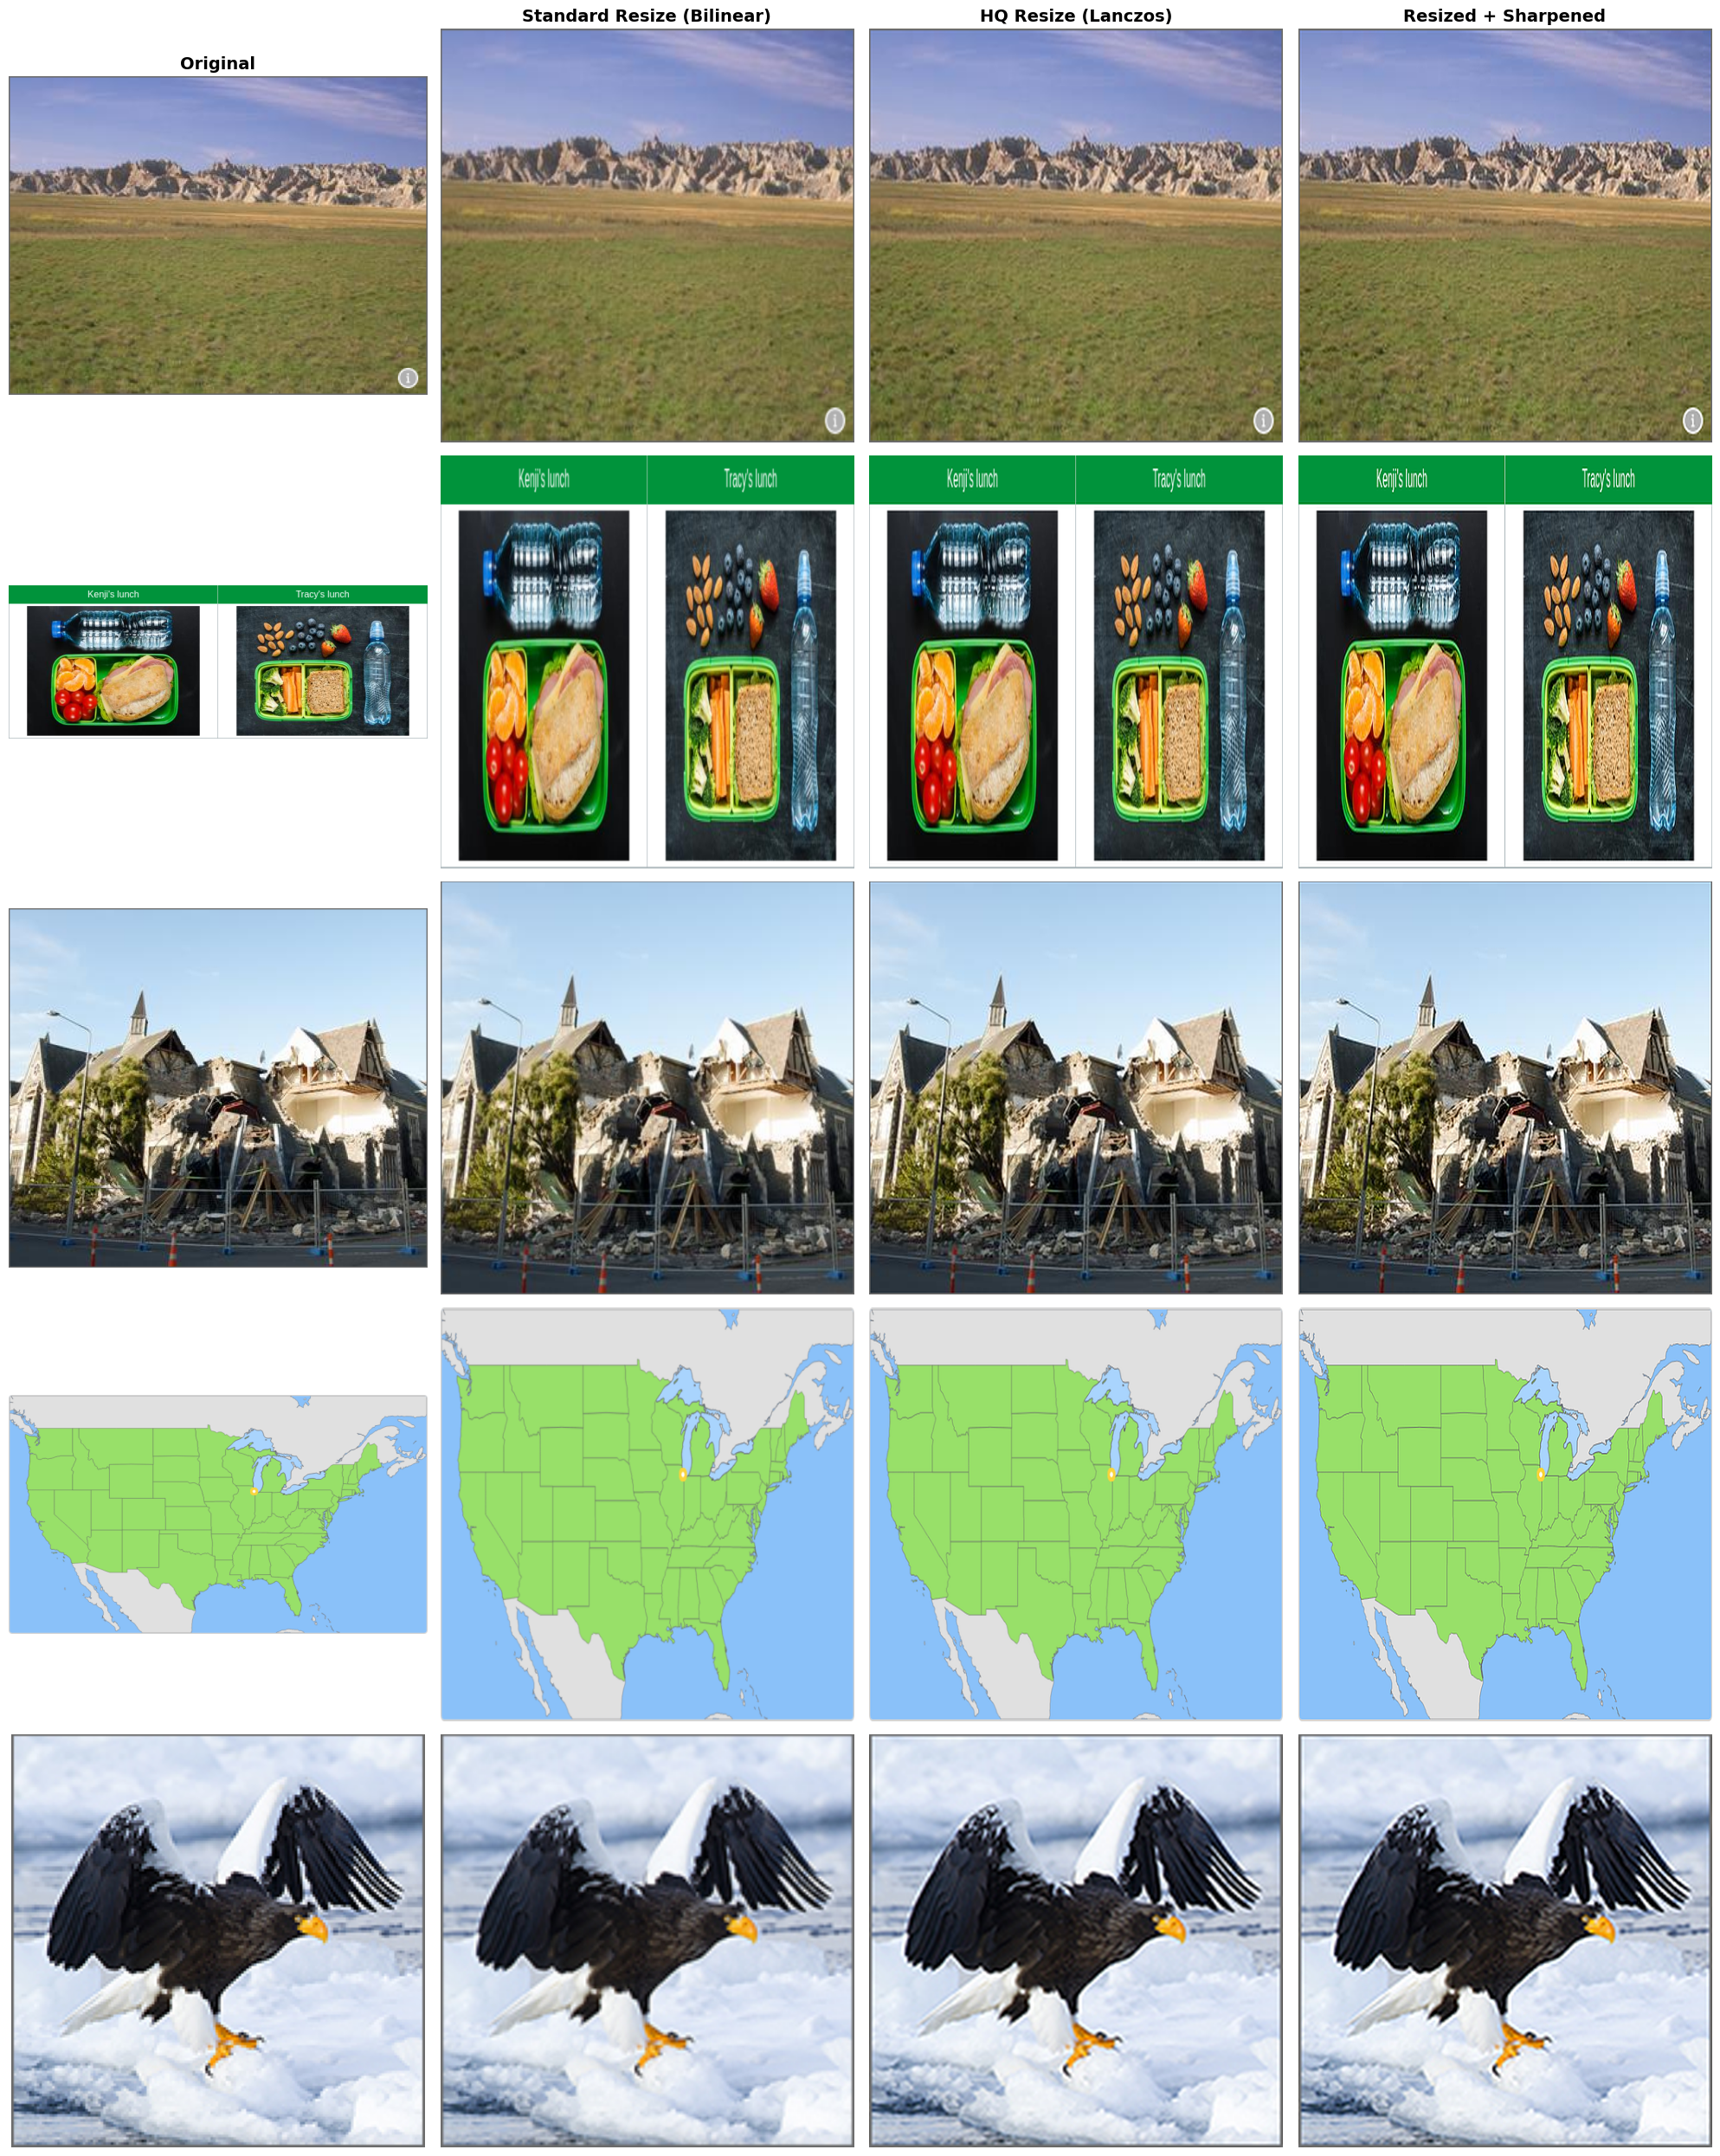

In [ ]:
# import random
# import matplotlib.pyplot as plt
# from PIL import Image, ImageEnhance

# def visualize_blur_impact(directory, target_size=512, samples=5):
#     files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg'))]
#     selected = random.sample(files, samples)

#     fig, axes = plt.subplots(samples, 4, figsize=(20, 5 * samples))
#     cols = ["Original", "Standard Resize (Bilinear)", "HQ Resize (Lanczos)", "Resized + Sharpened"]

#     for i, filename in enumerate(selected):
#         path = os.path.join(directory, filename)
#         orig = Image.open(path).convert("RGB")

#         # Standard Resize (what happens by default)
#         # Note: Most models default to Bilinear, which is fast but blurry
#         bilinear = orig.resize((target_size, target_size), resample=Image.BILINEAR)

#         # High Quality Resize
#         lanczos = orig.resize((target_size, target_size), resample=Image.LANCZOS)

#         # Resized + Augmented (The Fix)
#         enhancer = ImageEnhance.Sharpness(lanczos)
#         # Factor 2.0 = drastic sharpening to counter the 69% loss
#         sharpened = enhancer.enhance(2.0)

#         # Display
#         images = [orig, bilinear, lanczos, sharpened]
#         for j, img in enumerate(images):
#             axes[i, j].imshow(img)
#             if i == 0: axes[i, j].set_title(cols[j], fontsize=14, fontweight='bold')
#             axes[i, j].axis('off')

#     plt.tight_layout()
#     plt.show()

# # Run on your path
# visualize_blur_impact(IMAGE_TRAIN_DIR, target_size=IMG_SIZE)


In [ ]:
# import os
# from PIL import Image, ImageEnhance, ImageOps
# from tqdm import tqdm

# def refine_and_save(input_dir, output_dir, target_size=512):
#     # Create output directory if it doesn't exist
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)
#         print(f"Created: {output_dir}")

#     # Get image list
#     valid_extensions = ('.png', '.jpg', '.jpeg')
#     files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

#     print(f"Refining {len(files)} images from {input_dir}...")

#     for filename in tqdm(files):
#         try:
#             img_path = os.path.join(input_dir, filename)
#             img = Image.open(img_path).convert("RGB")

#             # PROPORTIONAL RESIZE (Prevents stretching/distortion)
#             img.thumbnail((target_size, target_size), Image.LANCZOS)

#             # WHITE PADDING (Maintains 512x512 square for SmolVLM)
#             delta_w = target_size - img.size[0]
#             delta_h = target_size - img.size[1]
#             padding = (delta_w//2, delta_h//2, delta_w-(delta_w//2), delta_h-(delta_h//2))
#             img = ImageOps.expand(img, padding, fill="white")

#             # SHARPNESS & CONTRAST (Fixing the 69% loss)
#             # Sharpness factor 2.5 makes thin lines bold for the vision encoder
#             img = ImageEnhance.Sharpness(img).enhance(2.5)
#             # Contrast factor 1.15 separates text from white background
#             img = ImageEnhance.Contrast(img).enhance(1.15)

#             # SAVE
#             img.save(os.path.join(output_dir, filename), quality=95)
#         except Exception as e:
#             print(f"Error processing {filename}: {e}")

In [ ]:
# # --- EXECUTION ---
# # Process all folders
# refine_and_save(IMAGE_TRAIN_DIR,  REFINED_IMAGE_TRAIN_DIR, target_size = IMG_SIZE)
# refine_and_save(IMAGE_VAL_DIR,  REFINED_IMAGE_VAL_DIR, target_size = IMG_SIZE)
# refine_and_save(IMAGE_TEST_DIR,  REFINED_IMAGE_TEST_DIR, target_size = IMG_SIZE)

# print("\nDONE! You can now point your training script to the '_refined' folders.")

# '''
# When you load these images for training, set do_resize=False and do_pad=False in your AutoProcessor,
# as we have already performed these steps. This ensures the processor doesn't accidentally re-blur them.
# (Setting do_resize=False and do_pad=False ended up negatively impacting performance; attention-related probably)
# '''

Created: /kaggle/working/images/images/train_refined
Refining 3109 images from /kaggle/input/competitions/pixels-to-predictions/images/images/train...


100%|██████████| 3109/3109 [02:05<00:00, 24.80it/s]


Created: /kaggle/working/images/images/val_refined
Refining 1048 images from /kaggle/input/competitions/pixels-to-predictions/images/images/val...


100%|██████████| 1048/1048 [00:41<00:00, 25.13it/s]


Created: /kaggle/working/images/images/test_refined
Refining 1008 images from /kaggle/input/competitions/pixels-to-predictions/images/images/test...


100%|██████████| 1008/1008 [00:40<00:00, 24.89it/s]


DONE! You can now point your training script to the '_refined' folders.


"\nWhen you load these images for training, set do_resize=False and do_pad=False in your AutoProcessor, \nas we have already performed these steps. This ensures the processor doesn't accidentally re-blur them.\n"

In [ ]:
# import os
# import shutil
# import pandas as pd
# from tqdm import tqdm

# def merge_datasets_and_update_csv(train_dir, val_dir, combined_output_dir, csv_path, mini_csv_path):
#     """
#     Merges images from two directories into one and updates the CSV paths.
#     """
#     # Create the unified image directory
#     os.makedirs(combined_output_dir, exist_ok=True)
#     print(f"Created unified directory: {combined_output_dir}")

#     # Copy images from train_refined
#     print(f"Copying {train_dir} images...")
#     for img in tqdm(os.listdir(train_dir)):
#         if img.endswith(('.png', '.jpg', '.jpeg')):
#             src = os.path.join(train_dir, img)
#             dst = os.path.join(combined_output_dir, img)
#             shutil.copy2(src, dst)

#     # Copy images from val_refined
#     print(f"Copying {val_dir} images...")
#     for img in tqdm(os.listdir(val_dir)):
#         if img.endswith(('.png', '.jpg', '.jpeg')):
#             src = os.path.join(val_dir, img)
#             dst = os.path.join(combined_output_dir, img)
#             shutil.copy2(src, dst)

#     # Update the CSV
#     print(f"Updating image paths in {csv_path}...")
#     df = pd.read_csv(csv_path)

#     # The original path looks like "images/train/train_0001.png".
#     # We extract just the filename ("train_0001.png") and prepend our new folder.
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#     )

#     # Overwrite the CSV (or save as a new one)
#     # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#     updated_csv_path = csv_path
#     df.to_csv(updated_csv_path, index=False)

#     print(f"Success! Updated CSV saved to: {updated_csv_path}")

#     if mini_csv_path:
#       # Update the mini CSV
#       print(f"Updating image paths in {mini_csv_path}...")
#       df = pd.read_csv(mini_csv_path)

#       # The original path looks like "images/train/train_0001.png".
#       # We extract just the filename ("train_0001.png") and prepend our new folder.
#       df['image_path'] = df['image_path'].apply(
#           lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#       )

#       # Overwrite the CSV (or save as a new one)
#       # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#       updated_csv_path = mini_csv_path
#       df.to_csv(updated_csv_path, index=False)

#       print(f"Success! Updated Mini CSV saved to: {updated_csv_path}")

# def update_csv(combined_output_dir, csv_path, mini_csv_path):
#     """
#     Merges images from two directories into one and updates the CSV paths.
#     """
#     # Update the CSV
#     print(f"Updating image paths in {csv_path}...")
#     df = pd.read_csv(csv_path)

#     # The original path looks like "images/train/train_0001.png".
#     # We extract just the filename ("train_0001.png") and prepend our new folder.
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#     )

#     # Overwrite the CSV (or save as a new one)
#     # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#     updated_csv_path = csv_path
#     df.to_csv(updated_csv_path, index=False)

#     print(f"Success! Updated CSV saved to: {updated_csv_path}")

#     if mini_csv_path:
#       # Update the mini CSV
#       print(f"Updating image paths in {mini_csv_path}...")
#       df = pd.read_csv(mini_csv_path)

#       # The original path looks like "images/train/train_0001.png".
#       # We extract just the filename ("train_0001.png") and prepend our new folder.
#       df['image_path'] = df['image_path'].apply(
#           lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#       )

#       # Overwrite the CSV (or save as a new one)
#       # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#       updated_csv_path = mini_csv_path
#       df.to_csv(updated_csv_path, index=False)

#       print(f"Success! Updated Mini CSV saved to: {updated_csv_path}")



In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= IMAGE_TRAIN_DIR,
#     val_dir= IMAGE_VAL_DIR,
#     combined_output_dir= IMAGE_TRAIN_VAL_DIR,
#     csv_path= KFOLD_CSV,
#     mini_csv_path= MINI_KFOLD_CSV 
# )

Created unified directory: /kaggle/working/images/images/train_val
Copying /kaggle/input/competitions/pixels-to-predictions/images/images/train images...


100%|██████████| 3109/3109 [00:27<00:00, 114.16it/s]


Copying /kaggle/input/competitions/pixels-to-predictions/images/images/val images...


100%|██████████| 1048/1048 [00:08<00:00, 116.84it/s]


Updating image paths in /kaggle/working/combined_train_folds_full_multilabel.csv...
Success! Updated CSV saved to: /kaggle/working/combined_train_folds_full_multilabel.csv
Updating image paths in /kaggle/working/combined_train_folds_mini_multilabel.csv...
Success! Updated Mini CSV saved to: /kaggle/working/combined_train_folds_mini_multilabel.csv


In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= REFINED_IMAGE_TRAIN_DIR,
#     val_dir= REFINED_IMAGE_VAL_DIR,
#     combined_output_dir= REFINED_IMAGE_TRAIN_VAL_DIR,
#     csv_path= KFOLD_512_CSV,
#     mini_csv_path= MINI_KFOLD_512_CSV
# )

Created unified directory: /kaggle/working/images/images/train_val_refined
Copying /kaggle/working/images/images/train_refined images...


100%|██████████| 3109/3109 [00:00<00:00, 4390.20it/s]


Copying /kaggle/working/images/images/val_refined images...


100%|██████████| 1048/1048 [00:00<00:00, 4132.03it/s]


Updating image paths in /kaggle/working/combined_train_folds_full_multilabel_512.csv...
Success! Updated CSV saved to: /kaggle/working/combined_train_folds_full_multilabel_512.csv
Updating image paths in /kaggle/working/combined_train_folds_mini_multilabel_512.csv...
Success! Updated Mini CSV saved to: /kaggle/working/combined_train_folds_mini_multilabel_512.csv


#### Resized Image Size (512x512) Token Analysis

In [ ]:
# from transformers import AutoProcessor
# from PIL import Image

# # Load your processor
# processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

# # Load one of your test images
# image_path = BASE_DIR / "images/images/train_val_refined/train_00000.png"
# image = Image.open(image_path).convert("RGB")

# # Create a dummy prompt
# text_prompt = "<image>\nAnswer the question."
# text_only_prompt = "Answer the question."

# # Tokenize WITH the image
# inputs_with_image = processor(
#     text=[text_prompt],
#     images=[image],
#     return_tensors="pt",
#     # Use the same settings as your training script!
#     do_resize=False,
#     do_pad=False
# )

# # Tokenize WITHOUT the image
# inputs_without_image = processor(
#     text=[text_only_prompt],
#     return_tensors="pt"
# )

# # Calculate the token lengths
# tokens_with_image = inputs_with_image["input_ids"].shape[1]
# tokens_without_image = inputs_without_image["input_ids"].shape[1]

# # The difference is exactly how many tokens the image occupies!
# image_token_cost = tokens_with_image - tokens_without_image

# print(f"Image Resolution: {image.size}")
# print(f"Tokens with image: {tokens_with_image}")
# print(f"Tokens without image: {tokens_without_image}")
# print(f"{'-'*40}")
# print(f"🖼️ EXACT IMAGE TOKEN COST: {image_token_cost} tokens")

Image Resolution: (512, 512)
Tokens with image: 72
Tokens without image: 4
----------------------------------------
🖼️ EXACT IMAGE TOKEN COST: 68 tokens


In [ ]:
# from transformers import AutoProcessor
# from PIL import Image

# # Load your processor
# processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

# # Load one of your test images
# image_path = BASE_DIR / "images/images/train_val_refined/train_00000.png"
# image = Image.open(image_path).convert("RGB")

# # Create a dummy prompt
# text_prompt = "<image>\nAnswer the question."
# text_only_prompt = "Answer the question."

# # Tokenize WITH the image
# inputs_with_image = processor(
#     text=[text_prompt],
#     images=[image],
#     return_tensors="pt",
#     # Use the same settings as your training script!
#     do_resize=True,
#     do_pad=True
# )

# # Tokenize WITHOUT the image
# inputs_without_image = processor(
#     text=[text_only_prompt],
#     return_tensors="pt"
# )

# # Calculate the token lengths
# tokens_with_image = inputs_with_image["input_ids"].shape[1]
# tokens_without_image = inputs_without_image["input_ids"].shape[1]

# # The difference is exactly how many tokens the image occupies!
# image_token_cost = tokens_with_image - tokens_without_image

# print(f"Image Resolution: {image.size}")
# print(f"Tokens with image: {tokens_with_image}")
# print(f"Tokens without image: {tokens_without_image}")
# print(f"{'-'*40}")
# print(f"🖼️ EXACT IMAGE TOKEN COST: {image_token_cost} tokens")

Image Resolution: (512, 512)
Tokens with image: 1132
Tokens without image: 4
----------------------------------------
🖼️ EXACT IMAGE TOKEN COST: 1128 tokens


#### Original Image Size Token Analysis

In [ ]:
# from transformers import AutoProcessor
# from PIL import Image

# # Load your processor
# processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

# # Load one of your test images
# image_path = BASE_DIR / "images/images/train_val/train_00000.png"
# image = Image.open(image_path).convert("RGB")

# # Create a dummy prompt
# text_prompt = "<image>\nAnswer the question."
# text_only_prompt = "Answer the question."

# # Tokenize WITH the image
# inputs_with_image = processor(
#     text=[text_prompt],
#     images=[image],
#     return_tensors="pt",
#     # Use the same settings as your training script!
#     do_resize=False,
#     do_pad=False
# )

# # Tokenize WITHOUT the image
# inputs_without_image = processor(
#     text=[text_only_prompt],
#     return_tensors="pt"
# )

# # Calculate the token lengths
# tokens_with_image = inputs_with_image["input_ids"].shape[1]
# tokens_without_image = inputs_without_image["input_ids"].shape[1]

# # The difference is exactly how many tokens the image occupies!
# image_token_cost = tokens_with_image - tokens_without_image

# print(f"Image Resolution: {image.size}")
# print(f"Tokens with image: {tokens_with_image}")
# print(f"Tokens without image: {tokens_without_image}")
# print(f"{'-'*40}")
# print(f"🖼️ EXACT IMAGE TOKEN COST: {image_token_cost} tokens")

Image Resolution: (750, 429)
Tokens with image: 338
Tokens without image: 4
----------------------------------------
🖼️ EXACT IMAGE TOKEN COST: 334 tokens


In [ ]:
# from transformers import AutoProcessor
# from PIL import Image

# # Load your processor
# processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

# # Load one of your test images
# image_path = BASE_DIR / "images/images/train_val/train_00000.png"
# image = Image.open(image_path).convert("RGB")

# # Create a dummy prompt
# text_prompt = "<image>\nAnswer the question."
# text_only_prompt = "Answer the question."

# # Tokenize WITH the image
# inputs_with_image = processor(
#     text=[text_prompt],
#     images=[image],
#     return_tensors="pt",
#     # Use the same settings as your training script!
#     do_resize=True,
#     do_pad=True
# )

# # Tokenize WITHOUT the image
# inputs_without_image = processor(
#     text=[text_only_prompt],
#     return_tensors="pt"
# )

# # Calculate the token lengths
# tokens_with_image = inputs_with_image["input_ids"].shape[1]
# tokens_without_image = inputs_without_image["input_ids"].shape[1]

# # The difference is exactly how many tokens the image occupies!
# image_token_cost = tokens_with_image - tokens_without_image

# print(f"Image Resolution: {image.size}")
# print(f"Tokens with image: {tokens_with_image}")
# print(f"Tokens without image: {tokens_without_image}")
# print(f"{'-'*40}")
# print(f"🖼️ EXACT IMAGE TOKEN COST: {image_token_cost} tokens")

Image Resolution: (750, 429)
Tokens with image: 867
Tokens without image: 4
----------------------------------------
🖼️ EXACT IMAGE TOKEN COST: 863 tokens


#### 224 x 224 Image Resizing Experiment Setup

In [ ]:
# # ---------------------------------------------------------
# # ACTION 1: Create the FULL Multilabel Stratified Dataset
# # ---------------------------------------------------------
# full_folds_df = create_multilabel_folds(
#     combined_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=KFOLD_224_CSV
# )

# # ---------------------------------------------------------
# # ACTION 2: Create the MINI Multilabel Stratified Dataset
# # ---------------------------------------------------------
# # First, safely extract a 20% chunk. We stratify this initial extraction
# # by 'answer' to ensure the subset perfectly mirrors the target distribution.
# mini_df, _ = train_test_split(
#     combined_df,
#     train_size=0.20,
#     stratify=combined_df['answer'],
#     random_state=SEED
# )
# mini_df = mini_df.reset_index(drop=True)

# # Now, apply the 5-Fold Multilabel Stratification to the mini subset
# mini_folds_df = create_multilabel_folds(
#     mini_df,
#     num_folds=5,
#     stratify_cols=['answer', 'topic'],
#     output_filename=MINI_KFOLD_224_CSV
# )

Creating 5 folds for 4157 rows, stratifying by: ['answer', 'topic']
 ~ Saved /kaggle/working/combined_train_folds_full_multilabel_224.csv

Creating 5 folds for 831 rows, stratifying by: ['answer', 'topic']
 ~ Saved /kaggle/working/combined_train_folds_mini_multilabel_224.csv



In [ ]:
# # --- EXECUTION ---
# # Process all folders
# refine_and_save(IMAGE_TRAIN_DIR, REFINED_IMAGE_TRAIN_224_DIR, target_size = IMG_SIZE_224)
# refine_and_save(IMAGE_VAL_DIR, REFINED_IMAGE_VAL_224_DIR, target_size = IMG_SIZE_224)
# refine_and_save(IMAGE_TEST_DIR, REFINED_IMAGE_TEST_224_DIR, target_size = IMG_SIZE_224)

# print("\nDONE! You can now point your training script to the '_refined_224' folders.")

Created: /kaggle/working/images/images/train_refined_224
Refining 3109 images from /kaggle/input/competitions/pixels-to-predictions/images/images/train...


100%|██████████| 3109/3109 [00:53<00:00, 58.38it/s]


Created: /kaggle/working/images/images/val_refined_224
Refining 1048 images from /kaggle/input/competitions/pixels-to-predictions/images/images/val...


100%|██████████| 1048/1048 [00:17<00:00, 59.43it/s]


Created: /kaggle/working/images/images/test_refined_224
Refining 1008 images from /kaggle/input/competitions/pixels-to-predictions/images/images/test...


100%|██████████| 1008/1008 [00:16<00:00, 59.39it/s]


DONE! You can now point your training script to the '_refined_224' folders.


In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= REFINED_IMAGE_TRAIN_224_DIR,
#     val_dir=REFINED_IMAGE_VAL_224_DIR,
#     combined_output_dir= REFINED_IMAGE_TRAIN_VAL_224_DIR,
#     csv_path=KFOLD_224_CSV,
#     mini_csv_path=MINI_KFOLD_224_CSV 
# )

Created unified directory: /kaggle/working/images/images/train_val_refined_224
Copying /kaggle/working/images/images/train_refined_224 images...


100%|██████████| 3109/3109 [00:00<00:00, 5955.28it/s]


Copying /kaggle/working/images/images/val_refined_224 images...


100%|██████████| 1048/1048 [00:00<00:00, 6721.12it/s]


Updating image paths in /kaggle/working/combined_train_folds_full_multilabel_224.csv...
Success! Updated CSV saved to: /kaggle/working/combined_train_folds_full_multilabel_224.csv
Updating image paths in /kaggle/working/combined_train_folds_mini_multilabel_224.csv...
Success! Updated Mini CSV saved to: /kaggle/working/combined_train_folds_mini_multilabel_224.csv


### Zero-Shot Inference

The Below Inference change was made and noted towards the very end of the training iterations (Initially, We opted for Prompt #4 {Persona Category} for the Number Indexed Choices since it performed better on a config run, but the Letter Choices variant ended up swaying towards Prompt #2 {Contextual}) \[In terms of Performance, Prompt Config #4 still outperformed Prompt Config #2\]

#### Zero-Shot Inference Setup (For Number and Letter Variants)

In [ ]:
# import json
# import pandas as pd

# def safe_get(val):
#     """Safely extracts text, returning an empty string for NaNs."""
#     if pd.isna(val) or str(val).lower().strip() == 'nan':
#         return ""
#     return str(val).strip()

# def format_choices_numbered(choices_raw):
#     """Parses the JSON choices into a clean numbered list string."""
#     try:
#         choices_list = json.loads(choices_raw)
#     except:
#         choices_list = eval(choices_raw)

#     return "\n".join([f"{idx}: {choice}" for idx, choice in enumerate(choices_list)])

# # ==========================================
# # CONFIG 1: The Minimalist Numbered
# # ==========================================
# def prompt_config_1_minimal_numbered(row):
#     question = safe_get(row['question'])
#     choices_str = format_choices_numbered(row['choices'])
#     return (
#         f"<image>\n"
#         f"Question: {question}\n"
#         f"Choices:\n{choices_str}\n\n"
#         f"Output ONLY the integer index of the correct answer.\nAnswer:"
#     )

# # ==========================================
# # CONFIG 2: The Context-Heavy Numbered
# # ==========================================
# def prompt_config_2_contextual_numbered(row):
#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices_numbered(row['choices'])

#     parts = []

#     parts.append("<image>\n")

#     if lecture: parts.append(f"Context: {lecture}")
#     if hint: parts.append(f"Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Choices:\n{choices_str}")
#     parts.append("\nBased on the image and context provided, output ONLY the integer index of the correct answer.\nAnswer:")

#     return "\n".join(parts)

# # ==========================================
# # CONFIG 3: The Persona-Driven Numbered
# # ==========================================
# def prompt_config_3_persona_numbered(row):
#     # Extract Metadata
#     subject = safe_get(row.get('subject')).title()
#     grade = safe_get(row.get('grade')).replace('grade', 'Grade ')
#     topic = safe_get(row.get('topic')).replace('-', ' ').title()
#     skill = safe_get(row.get('skill'))

#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices_numbered(row['choices'])

#     parts = []

#     parts.append("<image>\n")

#     parts.append(f"You are an expert taking a {grade} {subject} exam on the topic of {topic}.")
#     if skill: parts.append(f"Your goal is to demonstrate this skill: {skill}")
#     parts.append("---")

#     if lecture: parts.append(f"Background Context: {lecture}")
#     if hint: parts.append(f"Helpful Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Options:\n{choices_str}")
#     parts.append("---")
#     parts.append("Analyze the image and text above. Output ONLY the integer index of the correct option.\nAnswer:")

#     return "\n".join(parts)

# # ==========================================
# # CONFIG 4: The Hyper-Specific Persona Numbered (Topic + Category)
# # ==========================================
# def prompt_config_4_category_persona_numbered(row):
#     # Extract Metadata
#     subject = safe_get(row.get('subject')).title()
#     grade = safe_get(row.get('grade')).replace('grade', 'Grade ')
#     topic = safe_get(row.get('topic')).replace('-', ' ').title()
#     category = safe_get(row.get('category')).title()
#     skill = safe_get(row.get('skill'))

#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices_numbered(row['choices'])

#     parts = []
#     parts.append("<image>")

#     # Build the deeply nested Persona
#     persona_intro = f"You are an expert taking a {grade} {subject} exam."

#     # Gracefully handle if Topic or Category are missing
#     if topic and category:
#         persona_intro += f" The focus of this exam is {topic} ({category})."
#     elif topic:
#         persona_intro += f" The focus of this exam is {topic}."
#     elif category:
#         persona_intro += f" The focus of this exam is {category}."

#     parts.append(persona_intro)

#     if skill:
#         parts.append(f"Your goal is to demonstrate this skill: {skill}")

#     parts.append("---")

#     # Add Context and Question
#     if lecture: parts.append(f"Background Context: {lecture}")
#     if hint: parts.append(f"Helpful Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Options:\n{choices_str}")
#     parts.append("---")

#     # The Zero-Shot Instruction
#     parts.append("Analyze the image and text above. Output ONLY the integer index of the correct option.\nAnswer:")

#     return "\n".join(parts)

In [ ]:
# import json
# import pandas as pd

# def safe_get(val):
#     """Safely extracts text, returning an empty string for NaNs."""
#     if pd.isna(val) or str(val).lower().strip() == 'nan':
#         return ""
#     return str(val).strip()

# def format_choices(choices_raw):
#     """Parses the JSON choices into a clean lettered list string."""
#     CHOICE_LETTERS = "ABCDEFGHIJ"
#     try:
#         choices_list = json.loads(choices_raw)
#     except:
#         choices_list = eval(choices_raw)
#     return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

# # ==========================================
# # CONFIG 1: The Minimalist
# # ==========================================
# def prompt_config_1_minimal(row):
#     question = safe_get(row['question'])
#     choices_str = format_choices(row['choices'])
#     return (
#         f"<image>\n"
#         f"Question: {question}\n"
#         f"Choices:\n{choices_str}\n\n"
#         f"Output ONLY the letter of the correct choice.\nAnswer:"
#     )

# # ==========================================
# # CONFIG 2: The Context-Heavy
# # ==========================================
# def prompt_config_2_contextual(row):
#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices(row['choices'])

#     parts = []

#     parts.append("<image>\n")

#     if lecture: parts.append(f"Context: {lecture}")
#     if hint: parts.append(f"Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Choices:\n{choices_str}")
#     parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.\nAnswer:")

#     return "\n".join(parts)

# # ==========================================
# # CONFIG 3: The Persona-Driven
# # ==========================================
# def prompt_config_3_persona(row):
#     # Extract Metadata
#     subject = safe_get(row.get('subject')).title()
#     grade = safe_get(row.get('grade')).replace('grade', 'Grade ')
#     topic = safe_get(row.get('topic')).replace('-', ' ').title()
#     skill = safe_get(row.get('skill'))

#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices(row['choices'])

#     parts = []

#     parts.append("<image>\n")

#     parts.append(f"You are an expert taking a {grade} {subject} exam on the topic of {topic}.")
#     if skill: parts.append(f"Your goal is to demonstrate this skill: {skill}")
#     parts.append("---")

#     if lecture: parts.append(f"Background Context: {lecture}")
#     if hint: parts.append(f"Helpful Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Options:\n{choices_str}")
#     parts.append("---")
#     parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.\nAnswer:")

#     return "\n".join(parts)

# # ==========================================
# # CONFIG 4: The Hyper-Specific Persona (Topic + Category)
# # ==========================================
# def prompt_config_4_category_persona(row):
#     # Extract Metadata
#     subject = safe_get(row.get('subject')).title()
#     grade = safe_get(row.get('grade')).replace('grade', 'Grade ')
#     topic = safe_get(row.get('topic')).replace('-', ' ').title()
#     category = safe_get(row.get('category')).title()
#     skill = safe_get(row.get('skill'))

#     lecture = safe_get(row.get('lecture'))
#     hint = safe_get(row.get('hint'))
#     question = safe_get(row['question'])
#     choices_str = format_choices(row['choices'])

#     parts = []
#     parts.append("<image>")

#     # Build the deeply nested Persona
#     persona_intro = f"You are an expert taking a {grade} {subject} exam."

#     # Gracefully handle if Topic or Category are missing
#     if topic and category:
#         persona_intro += f" The focus of this exam is {topic} ({category})."
#     elif topic:
#         persona_intro += f" The focus of this exam is {topic}."
#     elif category:
#         persona_intro += f" The focus of this exam is {category}."

#     parts.append(persona_intro)

#     if skill:
#         parts.append(f"Your goal is to demonstrate this skill: {skill}")

#     parts.append("---")

#     # Add Context and Question
#     if lecture: parts.append(f"Background Context: {lecture}")
#     if hint: parts.append(f"Helpful Hint: {hint}")

#     parts.append(f"Question: {question}")
#     parts.append(f"Options:\n{choices_str}")
#     parts.append("---")

#     # The Zero-Shot Instruction
#     parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.\nAnswer:")

#     return "\n".join(parts)

#### 512 x 512 Zero-Shot Inference For Numbered Choices

In [ ]:
# import pandas as pd
# import torch
# import re
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq

# # Configuration Setup
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# print(f"Loading Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Uses half-precision to save memory
# ).to(DEVICE)
# model.eval() # Set to evaluation mode

# # Load the Mini Dataset & Sample 200 rows
# # Make sure you point this to your actual image directory (e.g., the preprocessed 512x512 ones)
# IMAGE_DIR = REFINED_IMAGE_TRAIN_VAL_DIR # <-- Update this to your image path
# df = pd.read_csv(MINI_KFOLD_512_CSV)
# eval_df = df.sample(200, random_state=SEED).reset_index(drop=True)

# configs = {
#     "Config 1 (Minimal Numbered)": prompt_config_1_minimal_numbered,
#     "Config 2 (Contextual Numbered)": prompt_config_2_contextual_numbered,
#     "Config 3 (Persona Numbered)": prompt_config_3_persona_numbered,
#     "Config 4 (Category Persona Numbered)": prompt_config_4_category_persona_numbered
# }

# results = {k: 0 for k in configs.keys()}
# total_valid_samples = len(eval_df)

# print("\nStarting Numbered Zero-Shot Evaluation...")

# # The Inference Loop
# with torch.inference_mode():
#     for name, prompt_func in configs.items():
#         print(f"\nEvaluating {name}...")
#         correct_predictions = 0

#         for idx, row in tqdm(eval_df.iterrows(), total=total_valid_samples, disable=False, ascii=True):
#             try:
#                 # Load Image
#                 img_path = IMAGE_DIR / row['image_path'].split('/')[-1]
#                 image = Image.open(img_path).convert("RGB")

#                 # Generate Prompt
#                 prompt_text = prompt_func(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False, # Crucial for Train-Inference Alignment
#                     do_pad=False     # Crucial for Train-Inference Alignment
#                 ).to(DEVICE)

#                 # Generate Answer
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=5, # We only need the integer
#                     do_sample=False,  # Greedy decoding for facts
#                     temperature=None,
#                     top_p=None
#                 )

#                 # Decode the output (skip the prompt text to just get the new generation)
#                 generated_text = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extract the first integer from the output using Regex
#                 # E.g., if model outputs "The answer is 2", this grabs '2'
#                 match = re.search(r'\d+', generated_text)

#                 if match:
#                     predicted_ans = int(match.group())
#                     if predicted_ans == int(row['answer']):
#                         correct_predictions += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#         # Calculate Accuracy
#         accuracy = (correct_predictions / total_valid_samples) * 100
#         results[name] = accuracy
#         print(f"Accuracy for {name}: {accuracy:.2f}%")

# print("\n=== FINAL ZERO-SHOT RESULTS ===")
# for name, acc in results.items():
#     print(f"{name}: {acc:.2f}%")

Loading Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



Starting Numbered Zero-Shot Evaluation...

Evaluating Config 1 (Minimal Numbered)...


100%|##########| 200/200 [01:12<00:00,  2.76it/s]


Accuracy for Config 1 (Minimal Numbered): 43.50%

Evaluating Config 2 (Contextual Numbered)...


...

Accuracy for Config 2 (Contextual Numbered): 51.00%

Evaluating Config 3 (Persona Numbered)...


100%|##########| 200/200 [01:24<00:00,  2.36it/s]


Accuracy for Config 3 (Persona Numbered): 56.50%

Evaluating Config 4 (Category Persona Numbered)...


100%|##########| 200/200 [01:25<00:00,  2.35it/s]

Accuracy for Config 4 (Category Persona Numbered): 54.50%

=== FINAL ZERO-SHOT RESULTS ===
Config 1 (Minimal Numbered): 43.50%
Config 2 (Contextual Numbered): 51.00%
Config 3 (Persona Numbered): 56.50%
Config 4 (Category Persona Numbered): 54.50%


#### 224 x 224 Zero-Shot Inference For Numbered Choices

In [ ]:
# import pandas as pd
# import torch
# import re
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq

# # Configuration Setup
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# print(f"Loading Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Uses half-precision to save memory
# ).to(DEVICE)
# model.eval() # Set to evaluation mode

# # Load the Mini Dataset & Sample 200 rows
# # Make sure you point this to your actual image directory (e.g., the preprocessed 224x224 ones)
# IMAGE_DIR = REFINED_IMAGE_TRAIN_VAL_224_DIR # <-- Update this to your image path
# df = pd.read_csv(MINI_KFOLD_224_CSV)
# eval_df = df.sample(200, random_state=SEED).reset_index(drop=True)

# configs = {
#     "Config 1 (Minimal Numbered)": prompt_config_1_minimal_numbered,
#     "Config 2 (Contextual Numbered)": prompt_config_2_contextual_numbered,
#     "Config 3 (Persona Numbered)": prompt_config_3_persona_numbered,
#     "Config 4 (Category Persona Numbered)": prompt_config_4_category_persona_numbered
# }

# results = {k: 0 for k in configs.keys()}
# total_valid_samples = len(eval_df)

# print("\nStarting Numbered Zero-Shot Evaluation...")

# # The Inference Loop
# with torch.inference_mode():
#     for name, prompt_func in configs.items():
#         print(f"\nEvaluating {name}...")
#         correct_predictions = 0

#         for idx, row in tqdm(eval_df.iterrows(), total=total_valid_samples, disable=False, ascii=True):
#             try:
#                 # Load Image
#                 img_path = IMAGE_DIR / row['image_path'].split('/')[-1]
#                 image = Image.open(img_path).convert("RGB")

#                 # Generate Prompt
#                 prompt_text = prompt_func(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False, # Crucial for Train-Inference Alignment
#                     do_pad=False     # Crucial for Train-Inference Alignment
#                 ).to(DEVICE)

#                 # Generate Answer
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=5, # We only need the integer
#                     do_sample=False,  # Greedy decoding for facts
#                     temperature=None,
#                     top_p=None
#                 )

#                 # Decode the output (skip the prompt text to just get the new generation)
#                 generated_text = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extract the first integer from the output using Regex
#                 # E.g., if model outputs "The answer is 2", this grabs '2'
#                 match = re.search(r'\d+', generated_text)

#                 if match:
#                     predicted_ans = int(match.group())
#                     if predicted_ans == int(row['answer']):
#                         correct_predictions += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#         # Calculate Accuracy
#         accuracy = (correct_predictions / total_valid_samples) * 100
#         results[name] = accuracy
#         print(f"Accuracy for {name}: {accuracy:.2f}%")

# print("\n=== FINAL ZERO-SHOT RESULTS ===")
# for name, acc in results.items():
#     print(f"{name}: {acc:.2f}%")

Loading Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



Starting Numbered Zero-Shot Evaluation...

Evaluating Config 1 (Minimal Numbered)...


100%|##########| 200/200 [01:11<00:00,  2.79it/s]


Accuracy for Config 1 (Minimal Numbered): 45.50%

Evaluating Config 2 (Contextual Numbered)...


...

Accuracy for Config 2 (Contextual Numbered): 53.00%

Evaluating Config 3 (Persona Numbered)...


100%|##########| 200/200 [01:25<00:00,  2.34it/s]


Accuracy for Config 3 (Persona Numbered): 52.50%

Evaluating Config 4 (Category Persona Numbered)...


100%|##########| 200/200 [01:25<00:00,  2.33it/s]

Accuracy for Config 4 (Category Persona Numbered): 52.00%

=== FINAL ZERO-SHOT RESULTS ===
Config 1 (Minimal Numbered): 45.50%
Config 2 (Contextual Numbered): 53.00%
Config 3 (Persona Numbered): 52.50%
Config 4 (Category Persona Numbered): 52.00%


#### 512 x 512 Zero-Shot Inference For Letter Choices

In [ ]:
# import pandas as pd
# import torch
# import re
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq

# # Configuration Setup
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# print(f"Loading Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Uses half-precision to save memory
# ).to(DEVICE)
# model.eval() # Set to evaluation mode

# # Load the Mini Dataset & Sample 100 rows
# # Make sure you point this to your actual image directory (e.g., the preprocessed 512x512 ones)
# IMAGE_DIR = REFINED_IMAGE_TRAIN_VAL_DIR # <-- Update this to your image path
# df = pd.read_csv(MINI_KFOLD_512_CSV)
# eval_df = df.sample(200, random_state=SEED).reset_index(drop=True)

# configs = {
#     "Config 1 (Minimal)": prompt_config_1_minimal,
#     "Config 2 (Contextual)": prompt_config_2_contextual,
#     "Config 3 (Persona)": prompt_config_3_persona,
#     "Config 4 (Category Persona)": prompt_config_4_category_persona
# }

# results = {k: 0 for k in configs.keys()}
# total_valid_samples = len(eval_df)

# print("\nStarting Zero-Shot Evaluation...")

# # The Inference Loop
# with torch.inference_mode():
#     for name, prompt_func in configs.items():
#         print(f"\nEvaluating {name}...")
#         correct_predictions = 0

#         for idx, row in tqdm(eval_df.iterrows(), total=total_valid_samples, disable=False, ascii=True):
#             try:
#                 # Load Image
#                 img_path = IMAGE_DIR / row['image_path'].split('/')[-1]
#                 image = Image.open(img_path).convert("RGB")

#                 # Generate Prompt
#                 prompt_text = prompt_func(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False, # Crucial for Train-Inference Alignment
#                     do_pad=False     # Crucial for Train-Inference Alignment
#                 ).to(DEVICE)

#                 # Generate Answer
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=5, # We only need the integer
#                     do_sample=False,  # Greedy decoding for facts
#                     temperature=None,
#                     top_p=None
#                 )

#                 # Decode the output (skip the prompt text to just get the new generation)
#                 generated_text = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extract the first Standalone Uppercase letter from the output using Regex
#                 # E.g., if model outputs "A", this grabs 'A'
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 # Baseline Extraction: Look for a standalone uppercase letter
#                 match = re.search(r'\b([A-J])\b', generated_text)
#                 if match:
#                     predicted_idx = letter_to_index[match.group(1).upper()]
#                     if predicted_idx == int(row['answer']):
#                         correct_predictions += 1
#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#         # Calculate Accuracy
#         accuracy = (correct_predictions / total_valid_samples) * 100
#         results[name] = accuracy
#         print(f"Accuracy for {name}: {accuracy:.2f}%")

# print("\n=== FINAL ZERO-SHOT RESULTS ===")
# for name, acc in results.items():
#     print(f"{name}: {acc:.2f}%")

Loading Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



Starting Zero-Shot Evaluation...

Evaluating Config 1 (Minimal)...


100%|##########| 200/200 [01:12<00:00,  2.75it/s]


Accuracy for Config 1 (Minimal): 52.50%

Evaluating Config 2 (Contextual)...


...

Accuracy for Config 2 (Contextual): 65.00%

Evaluating Config 3 (Persona)...


100%|##########| 200/200 [01:26<00:00,  2.31it/s]


Accuracy for Config 3 (Persona): 54.50%

Evaluating Config 4 (Category Persona)...


100%|##########| 200/200 [01:26<00:00,  2.30it/s]

Accuracy for Config 4 (Category Persona): 53.50%

=== FINAL ZERO-SHOT RESULTS ===
Config 1 (Minimal): 52.50%
Config 2 (Contextual): 65.00%
Config 3 (Persona): 54.50%
Config 4 (Category Persona): 53.50%


#### 224 x 224 Zero-Shot Inference For Letter Choices

In [ ]:
# import pandas as pd
# import torch
# import re
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq

# # Configuration Setup
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# print(f"Loading Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Uses half-precision to save memory
# ).to(DEVICE)
# model.eval() # Set to evaluation mode

# # Load the Mini Dataset & Sample 200 rows
# # Make sure you point this to your actual image directory (e.g., the preprocessed 224x224 ones)
# IMAGE_DIR = REFINED_IMAGE_TRAIN_VAL_224_DIR # <-- Update this to your image path
# df = pd.read_csv(MINI_KFOLD_224_CSV)
# eval_df = df.sample(200, random_state=SEED).reset_index(drop=True)

# # Define the 4 prompt functions here if you haven't already
# configs = {
#     "Config 1 (Minimal)": prompt_config_1_minimal,
#     "Config 2 (Contextual)": prompt_config_2_contextual,
#     "Config 3 (Persona)": prompt_config_3_persona,
#     "Config 4 (Category Persona)": prompt_config_4_category_persona
# }

# results = {k: 0 for k in configs.keys()}
# total_valid_samples = len(eval_df)

# print("\nStarting Zero-Shot Evaluation...")

# # The Inference Loop
# with torch.inference_mode():
#     for name, prompt_func in configs.items():
#         print(f"\nEvaluating {name}...")
#         correct_predictions = 0

#         for idx, row in tqdm(eval_df.iterrows(), total=total_valid_samples, disable=False, ascii=True):
#             try:
#                 # Load Image
#                 img_path = IMAGE_DIR / row['image_path'].split('/')[-1]
#                 image = Image.open(img_path).convert("RGB")

#                 # Generate Prompt
#                 prompt_text = prompt_func(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False, # Crucial for Train-Inference Alignment
#                     do_pad=False     # Crucial for Train-Inference Alignment
#                 ).to(DEVICE)

#                 # Generate Answer
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=5, # We only need the integer
#                     do_sample=False,  # Greedy decoding for facts
#                     temperature=None,
#                     top_p=None
#                 )

#                 # Decode the output (skip the prompt text to just get the new generation)
#                 generated_text = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extract the first Standalone Uppercase letter from the output using Regex
#                 # E.g., if model outputs "A", this grabs 'A'
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 # Baseline Extraction: Look for a standalone uppercase letter
#                 match = re.search(r'\b([A-J])\b', generated_text)
#                 if match:
#                     predicted_idx = letter_to_index[match.group(1).upper()]
#                     if predicted_idx == int(row['answer']):
#                         correct_predictions += 1
#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#         # Calculate Accuracy
#         accuracy = (correct_predictions / total_valid_samples) * 100
#         results[name] = accuracy
#         print(f"Accuracy for {name}: {accuracy:.2f}%")

# print("\n=== FINAL ZERO-SHOT RESULTS ===")
# for name, acc in results.items():
#     print(f"{name}: {acc:.2f}%")

Loading Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



Starting Zero-Shot Evaluation...

Evaluating Config 1 (Minimal)...


100%|##########| 200/200 [01:11<00:00,  2.80it/s]


Accuracy for Config 1 (Minimal): 55.00%

Evaluating Config 2 (Contextual)...


...

Accuracy for Config 2 (Contextual): 60.50%

Evaluating Config 3 (Persona)...


100%|##########| 200/200 [01:25<00:00,  2.34it/s]


Accuracy for Config 3 (Persona): 53.00%

Evaluating Config 4 (Category Persona)...


100%|##########| 200/200 [01:25<00:00,  2.33it/s]

Accuracy for Config 4 (Category Persona): 52.00%

=== FINAL ZERO-SHOT RESULTS ===
Config 1 (Minimal): 55.00%
Config 2 (Contextual): 60.50%
Config 3 (Persona): 53.00%
Config 4 (Category Persona): 52.00%


#### Original Image + AutoProcessor Resize/Padding Zero-Shot Inference For Letter Choices

In [ ]:
# import pandas as pd
# import torch
# import re
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq

# # Configuration Setup
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# print(f"Loading Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Uses half-precision to save memory
# ).to(DEVICE)
# model.eval() # Set to evaluation mode

# # Load the Mini Dataset & Sample 200 rows
# # Make sure you point this to your actual original image directory
# IMAGE_DIR = IMAGE_TRAIN_VAL_DIR # <-- Update this to your image path
# df = pd.read_csv(MINI_KFOLD_CSV)
# eval_df = df.sample(200, random_state=SEED).reset_index(drop=True)

# configs = {
#     "Config 1 (Minimal)": prompt_config_1_minimal,
#     "Config 2 (Contextual)": prompt_config_2_contextual,
#     "Config 3 (Persona)": prompt_config_3_persona,
#     "Config 4 (Category Persona)": prompt_config_4_category_persona
# }

# results = {k: 0 for k in configs.keys()}
# total_valid_samples = len(eval_df)

# print("\nStarting Zero-Shot Evaluation...")

# # The Inference Loop
# with torch.inference_mode():
#     for name, prompt_func in configs.items():
#         print(f"\nEvaluating {name}...")
#         correct_predictions = 0

#         for idx, row in tqdm(eval_df.iterrows(), total=total_valid_samples, disable=False, ascii=True):
#             try:
#                 # Load Image
#                 img_path = IMAGE_DIR / row['image_path'].split('/')[-1]
#                 image = Image.open(img_path).convert("RGB")

#                 # Generate Prompt
#                 prompt_text = prompt_func(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True, # Crucial for Train-Inference Alignment
#                     do_pad=True     # Crucial for Train-Inference Alignment
#                 ).to(DEVICE)

#                 # Generate Answer
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=5, # We only need the integer
#                     do_sample=False,  # Greedy decoding for facts
#                     temperature=None,
#                     top_p=None
#                 )

#                 # Decode the output (skip the prompt text to just get the new generation)
#                 generated_text = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extract the first Standalone Uppercase letter from the output using Regex
#                 # E.g., if model outputs "A", this grabs 'A'
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 # Baseline Extraction: Look for a standalone uppercase letter
#                 match = re.search(r'\b([A-J])\b', generated_text)
#                 if match:
#                     predicted_idx = letter_to_index[match.group(1).upper()]
#                     if predicted_idx == int(row['answer']):
#                         correct_predictions += 1
#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#         # Calculate Accuracy
#         accuracy = (correct_predictions / total_valid_samples) * 100
#         results[name] = accuracy
#         print(f"Accuracy for {name}: {accuracy:.2f}%")

# print("\n=== FINAL ZERO-SHOT RESULTS ===")
# for name, acc in results.items():
#     print(f"{name}: {acc:.2f}%")

Loading Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



Starting Zero-Shot Evaluation...

Evaluating Config 1 (Minimal)...


100%|##########| 200/200 [08:19<00:00,  2.50s/it]


Accuracy for Config 1 (Minimal): 59.50%

Evaluating Config 2 (Contextual)...


...

Accuracy for Config 2 (Contextual): 68.00%

Evaluating Config 3 (Persona)...


100%|##########| 200/200 [08:48<00:00,  2.64s/it]


Accuracy for Config 3 (Persona): 59.00%

Evaluating Config 4 (Category Persona)...


100%|##########| 200/200 [08:50<00:00,  2.65s/it]

Accuracy for Config 4 (Category Persona): 60.50%

=== FINAL ZERO-SHOT RESULTS ===
Config 1 (Minimal): 59.50%
Config 2 (Contextual): 68.00%
Config 3 (Persona): 59.00%
Config 4 (Category Persona): 60.50%


#### Ignore the Image Processing Above, turns out it harms Performance I Believe? Default to the AutoProcessor for resizing, padding, normalizing, etc... Prompt 4 is still the best one.


(Before it was) Choose 512 x 512 Resizing + Prompt Config 3 (Persona) For Training

Update #1: Choose 512 x 512 Resizing + Prompt Config 4 (Category Persona) For Training

Update #2: We realized that Original Image with AutoProcessor resize/pad performed better, so use Prompt Config 4 with this setting.

**LATEST UPDATE: For Ablation #5.4, we used Prompt Config 2 for Training due to better Zero-Shot Inference performance (This discovery was made late) However, this Prompt Config 2 Usage ended up performing worse with the same training settings as Ablation #5.3 (Not accounting for DoRA), in spite of the better Zero-Shot Inference performance. As such, we continue to use Prompt Config 4, as usual, for the rest.**

(For Ablation 6: CoT, we also used Prompt Config 4)



### Test Dataset Image Path Updating

In [ ]:
# import os
# import pandas as pd

# def update_test_csv_paths(test_csv_path, img_dir, output_csv_path):
#     """
#     Updates the image paths in the test CSV to point to the new refined images directory.
#     """
#     print(f"Reading {test_csv_path}...")
#     df = pd.read_csv(test_csv_path)

#     # The original path looks like "images/test/test_0001.png".
#     # We extract just the filename ("test_0001.png") and prepend "test_refined"
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(img_dir, os.path.basename(x))
#     )

#     # Save the updated dataframe to a new CSV
#     df.to_csv(output_csv_path, index=False)
#     print(f" Success! Updated test CSV saved to: {output_csv_path}")

In [ ]:
# # --- Execute ---
# # This will take your original test.csv and create test_updated.csv
# update_test_csv_paths(
#     test_csv_path=TEST_CSV,
#     img_dir=REFINED_IMAGE_TEST_DIR, # The folder where your 512x512 test images are
#     output_csv_path=TEST_REFINED_CSV
# )

Reading /kaggle/input/competitions/pixels-to-predictions/test.csv...
 Success! Updated test CSV saved to: /kaggle/working/test_refined.csv


In [ ]:
# update_test_csv_paths(
#     test_csv_path=TEST_CSV,
#     img_dir=IMAGE_TEST_DIR, # The folder where your Original test images are
#     output_csv_path=TEST_ORIGINAL_CSV
# )

Reading /kaggle/input/competitions/pixels-to-predictions/test.csv...
 Success! Updated test CSV saved to: /kaggle/working/test_original.csv


### Synthesized Solutions for Missing Solutions in Train/Val/Combined_train_folds (CoT-Approach)

In [ ]:
# import google.generativeai as genai

# # Add your API Key from Google AI Studio (https://aistudio.google.com/api-keys?project=gen-lang-client-0374769805) here. Make sure to keep this secure and do NOT share it publicly.
# API_KEY = "Placeholder" # Replace with Placeholder when submitting Code
# genai.configure(api_key=API_KEY)

# print("Available Models for Generation:")
# for m in genai.list_models():
#     if 'generateContent' in m.supported_generation_methods:
#         print(m.name)

Available Models for Generation:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-r

In [ ]:
# import pandas as pd
# import google.generativeai as genai
# import time
# import json
# import os
# from PIL import Image
# from tqdm import tqdm
# import re

# # Setup Gemini API
# # Add your API Key from Google AI Studio (https://aistudio.google.com/api-keys?project=gen-lang-client-0374769805) here. Make sure to keep this secure and do NOT share it publicly.
# API_KEY = "Placeholder" # Replace with Placeholder when submitting Code
# genai.configure(api_key=API_KEY)
# model = genai.GenerativeModel('gemma-4-31b-it')

# # Load Dataset
# df = pd.read_csv(KFOLD_CSV)
# df_missing = df[df['solution'].isna()].copy()
# df_existing = df[df['solution'].notna()].copy()

# print(f"Found {len(df_missing)} rows to synthesize.")

# # The Formatting function
# def format_choices(choices_raw):
#     try:
#         choices_list = json.loads(choices_raw)
#     except:
#         choices_list = eval(choices_raw)
#     return "\n".join([f"{idx}: {choice}" for idx, choice in enumerate(choices_list)])

# # The Upgraded Multimodal Prompt Builder
# def build_synthesis_prompt(target_row, example_rows):
#     # Dynamically extract all hierarchical metadata
#     subject = str(target_row.get('subject', 'academic')).title()
#     grade = str(target_row.get('grade', '')).replace('grade', 'Grade ')
#     topic = str(target_row.get('topic', '')).title()
#     category = str(target_row.get('category', '')).title()
#     skill = str(target_row.get('skill', ''))

#     # Build a rich, dynamic Persona block
#     persona_parts = [f"You are an expert {grade} {subject} teacher."]

#     # Only add topic/category if they exist
#     if topic != "Nan" and category != "Nan":
#         persona_parts.append(f"You are writing a textbook explanation for a unit on {topic} ({category}).")

#     # Only add the skill if it exists
#     if skill and skill.lower() != "nan":
#         persona_parts.append(f"Your reasoning MUST demonstrate this specific skill to the student: {skill}.")

#     persona_intro = " ".join(persona_parts)

#     # Construct the prompt
#     prompt = f"""{persona_intro}
# Your task is to write the logical reasoning for a multiple-choice question based on the provided text AND the accompanying image.

# RULES:
# 1. Start directly with the explanation (e.g., "Look at the diagram...", "The text states..."). No conversational filler.
# 2. Base your reasoning STRICTLY on the provided Image, Hint, and Lecture.
# 3. Keep it concise (under 150 words).
# 4. CRITICAL: DO NOT conclude with the final answer. NEVER write phrases like "Therefore, the correct answer is X". Stop immediately after the reasoning is complete.
# 5. CRITICAL: You must wrap your final, polished explanation inside <rationale> and </rationale> tags.

# Here are two examples of the exact style I need:

# """
#     # Inject 2 Real Examples WITH CHOICES
#     for i, (_, row) in enumerate(example_rows.iterrows()):
#         prompt += f"--- EXAMPLE {i+1} ---\n"
#         prompt += f"Question: {row['question']}\n"
#         prompt += f"Options:\n{format_choices(row['choices'])}\n"
#         prompt += f"Hint: {row.get('hint', '')}\n"
#         prompt += f"Lecture: {row.get('lecture', '')}\n"
#         prompt += f"Correct Answer Index: {row['answer']}\n"
#         prompt += f"Target Rationale to Emulate: {row['solution']}\n\n"

#     # Inject Target Row WITH CHOICES
#     prompt += "--- NOW WRITE THE RATIONALE FOR THIS TARGET QUESTION (IMAGE PROVIDED IN REQUEST) ---\n"
#     prompt += f"Question: {target_row['question']}\n"
#     prompt += f"Options:\n{format_choices(target_row['choices'])}\n"
#     prompt += f"Hint: {target_row.get('hint', '')}\n"
#     prompt += f"Lecture: {target_row.get('lecture', '')}\n"
#     prompt += f"Correct Answer Index: {target_row['answer']}\n"
#     prompt += "Rationale:"

#     return prompt

# # Generation Loop
# synthetic_solutions = {}
# MAX_RETRIES = 3

# for idx, row in tqdm(df_missing.iterrows(), total=len(df_missing)):

#     # A. Preparation
#     subject = row.get('subject', 'natural science')
#     examples = df_existing[df_existing['subject'] == subject].sample(2, random_state=SEED)
#     prompt_text = build_synthesis_prompt(row, examples)

#     img_path = row['image_path']
#     if not os.path.exists(img_path):
#         img_path = img_path.split("/")[-1]

#     try:
#         image = Image.open(img_path).convert("RGB")
#     except Exception as e:
#         print(f"Failed to load image for {row['id']}: {e}")
#         continue

#     # B. The Retry Loop (Fixes the 500 Errors)
#     success = False
#     for attempt in range(MAX_RETRIES):
#         try:
#             response = model.generate_content([prompt_text, image])
#             raw_text = response.text.strip()
#             success = True
#             break # Break out of the retry loop on success!

#         except Exception as e:
#             print(f"\nAPI Error on row {row['id']} (Attempt {attempt + 1}/{MAX_RETRIES}): {e}")
#             time.sleep(10) # Wait 10 seconds before retrying this row

#     if not success:
#         print(f"Skipping row {row['id']} after {MAX_RETRIES} failed attempts.")
#         continue

#     # C. The Fault-Tolerant XML Extractor 
#     # 1st Try: Look for perfectly closed tags
#     match = re.search(r'<rationale>(.*?)</rationale>', raw_text, re.DOTALL | re.IGNORECASE)

#     if match:
#         synthetic_text = match.group(1).strip()
#     else:
#         # 2nd Try: The model forgot the closing tag. Grab everything after <rationale>
#         match_open = re.search(r'<rationale>(.*)', raw_text, re.DOTALL | re.IGNORECASE)
#         if match_open:
#             synthetic_text = match_open.group(1).strip()
#         else:
#             # Absolute worst case fallback
#             synthetic_text = raw_text

#     # D. The Gemma 4 Safety Net (Applied ONLY to the extracted text) 
#     forbidden_phrases = [
#         "therefore, the correct answer is",
#         "so, the answer is",
#         "the correct option is",
#         "the correct choice is",
#         "therefore, the probability is"
#     ]

#     lower_text = synthetic_text.lower()
#     for phrase in forbidden_phrases:
#         if phrase in lower_text:
#             cut_index = lower_text.rfind(phrase)
#             if cut_index > 0: # Ensure we don't accidentally delete the whole string
#                 synthetic_text = synthetic_text[:cut_index].strip()
#             print(f"For solution generation of row: {row['id']}, we found a forbidden phrase: {phrase}...\n")
#             print(lower_text)

#     # E. Store result and respect RPM limits
#     synthetic_solutions[idx] = synthetic_text
#     time.sleep(4.5)

# # Map the synthesized solutions back into the main DataFrame
# for idx, text in synthetic_solutions.items():
#     df.at[idx, 'solution'] = text

# df.to_csv(KFOLD_SYNTHESIZED_CSV, index=False)
# print("\n Dataset fully synthesized and saved!")

Found 701 rows to synthesize.


  1%|          | 5/701 [02:26<5:58:32, 30.91s/it]

For solution generation of row: train_11218, we found a forbidden phrase: therefore, the correct answer is...

` tags.

    *   question: probability that a pea plant produced by this cross will be *homozygous dominant* for the flower position gene?
    *   image: punnett square showing parents f and f crossing with f and f.
        *   box 1: ff
        *   box 2: ff
        *   box 3: ff
        *   box 4: ff
    *   hint: axial flowers (f) are dominant; terminal flowers (f) are recessive.
    *   lecture:
        *   homozygous dominant: two identical dominant alleles (ff).
        *   probability formula: number of ways event can happen / total number of equally likely outcomes.
        *   there are 4 boxes total.

    *   identify the target genotype: "homozygous dominant" means two identical dominant alleles, which is ff.
    *   look at the punnett square image: count how many boxes have the genotype ff. there is only 1 box with ff.
    *   identify total outcomes: there are 4 

  2%|▏         | 11/701 [05:25<5:37:55, 29.38s/it]

For solution generation of row: train_07522, we found a forbidden phrase: therefore, the probability is...

` tags.

    *   what is heterozygous? the lecture states: "an organism with two different alleles for a gene is heterozygous for that gene."
    *   looking at the punnett square: all four boxes contain the genotype "bb".
    *   are "bb" alleles different? no, they are the same (homozygous dominant).
    *   how many boxes are heterozygous (different alleles, like bb)? zero.
    *   total outcomes? four.
    *   probability calculation: $\frac{\text{number of heterozygous outcomes}}{\text{total outcomes}} = \frac{0}{4}$.

    *   *draft 1:* an organism is heterozygous if it has two different alleles for a gene. in the provided punnett square, every outcome is bb. since bb consists of two identical alleles, these offspring are homozygous, not heterozygous. there are zero boxes with different alleles (such as bb) out of the four total boxes. therefore, the probability is 0/4. (wa

...

For solution generation of row: val_01233, we found a forbidden phrase: therefore, the correct answer is...

` tags.

    *   lecture:
        *   elementary substances = composed of only one chemical element.
        *   compounds = composed of multiple chemical elements bonded together.
        *   ball-and-stick model: balls = atoms, sticks = bonds.
        *   different colors = different chemical elements.
    *   image:
        *   tetraphosphorus: 4 orange balls. (legend: orange = p)
        *   carbon tetraiodide: 1 black ball, 4 purple balls. (legend: black = c, purple = i)
        *   2-chloroethanol: green, black, white, red balls. (legend: green = cl, black = c, white = h, red = o)
    *   question: select the elementary substance.

    *   identify what an elementary substance is based on the lecture (one chemical element).
    *   explain how that looks in a model (all balls are the same color).
    *   analyze the three models:
        *   tetraphosphorus: all orange bal

 98%|█████████▊| 684/701 [5:27:44<08:12, 28.98s/it]

For solution generation of row: val_02940, we found a forbidden phrase: therefore, the correct answer is...

` tags.

    *   question: select the elementary substance.
    *   options: cyclooctasulfur, chloroform, fluoromethane.
    *   correct answer index: 0 (cyclooctasulfur).
    *   lecture:
        *   elementary substances = composed of only one chemical element.
        *   compounds = composed of multiple chemical elements bonded together.
        *   ball-and-stick model: balls = atoms, colors = different chemical elements.
    *   image analysis:
        *   cyclooctasulfur: only yellow balls (s).
        *   fluoromethane: black (c), white (h), and light green (f) balls.
        *   chloroform: black (c), white (h), and dark green (cl) balls.

    *   define an elementary substance based on the lecture: a substance composed of only one chemical element.
    *   explain the model: colors represent different elements.
    *   analyze cyclooctasulfur: only yellow balls are pre

100%|██████████| 701/701 [5:36:06<00:00, 28.77s/it]



 Dataset fully synthesized and saved!


In [ ]:
# import pandas as pd
# import re

# # Load the dataset you just generated
# df = pd.read_csv(KFOLD_SYNTHESIZED_CSV)

# def clean_rationale(text):
#     if pd.isna(text) or not isinstance(text, str):
#         return text

#     # Helper Function: The Ultimate Scrubber
#     def post_process(t):
#         # Chop off inline self-corrections
#         t = re.split(r'->\s*\*|\*\s*Wait|\*\s*Actually|\n\s*\*\s*Wait|\n\s*Wait,', t, flags=re.IGNORECASE)[0]

#         # Fix Spacing Issues (Compresses giant indents into standard newlines/spaces)
#         t = t.replace('\xa0', ' ') # Remove non-breaking spaces
#         t = re.sub(r'\n\s+', '\n', t) # Remove heavy indents at the start of new lines
#         t = re.sub(r' +', ' ', t) # Compress multiple inline spaces into one

#         # Catch rogue leftover headers (like "(Refining...):*")
#         t = re.sub(r'^\(.*?\):\*\s*', '', t)

#         # Strip leading asterisks, hyphens, and whitespace
#         t = re.sub(r'^[\s\*\-]+', '', t).strip()

#         # Strip wrapping quotes
#         t = re.sub(r'^"|"$', '', t).strip()
#         if t.startswith('"') and t.count('"') == 1:
#             t = t[1:].strip()

#         return t.strip()

#     extracted_text = None

#     # Scenario 1: The Tag Splitter 
#     parts = re.split(r'<rationale>', text, flags=re.IGNORECASE)
#     if len(parts) > 1:
#         candidate = parts[-1].lstrip()
#         if candidate.startswith('?') or candidate.startswith('`?'):
#             extracted_text = None
#         elif not re.search(r'\*(?:revised\s*)?draft|final polish', candidate, re.IGNORECASE):
#             extracted_text = re.sub(r'</rationale>', '', candidate, flags=re.IGNORECASE)

#     # Scenario 2: Severe truncation / Fake Tags 
#     if not extracted_text:
#         polish_match = re.search(r'\*+\s*final polish\s*\**:?\s*(.*?)(?=\n\s*\*|$)', text, re.DOTALL | re.IGNORECASE)
#         if polish_match:
#             extracted_text = polish_match.group(1)
#         else:
#             # UPGRADED DRAFT REGEX: Catches anything inside the draft header, even parentheses!
#             draft_matches = list(re.finditer(r'\*+\s*(?:revised\s*)?draft[^:\n]*[:\*]+\s*(.*?)(?=\n\s*\*|$)', text, re.DOTALL | re.IGNORECASE))
#             if draft_matches:
#                 extracted_text = draft_matches[-1].group(1)

#     # Scenario 3: Total fallback 
#     if not extracted_text:
#         extracted_text = text

#     cleaned_text = post_process(extracted_text)

#     # Scenario 4: The Garbage Detector 
#     garbage_markers = [
#         "*Hint:*", "*Lecture:*", "*Question:*", "` tags.",
#         "? Yes", "? yes", "Wait, Rule 4", "Let me rephrase",
#         "My draft ends with", "Actually, the rule is"
#     ]

#     for marker in garbage_markers:
#         if marker.lower() in cleaned_text.lower():
#             return pd.NA

#     return cleaned_text

# # Apply the cleaning function
# print("Cleaning generated solutions...")
# df['solution'] = df['solution'].apply(clean_rationale)

# # Save the cleaned version
# df.to_csv(KFOLD_SYNTHESIZED_CLEAN_CSV, index=False)
# print("Cleaned solutions saved!")

Cleaning generated solutions...
Cleaned solutions saved!


In [ ]:
# import pandas as pd
# import google.generativeai as genai
# import time
# import os
# import re
# from PIL import Image
# from tqdm import tqdm

# # The Cleaning Function 
# def clean_rationale(text):
#     if pd.isna(text) or not isinstance(text, str):
#         return text

#     def post_process(t):
#         t = re.split(r'->\s*\*|\*\s*Wait|\*\s*Actually|\n\s*\*\s*Wait|\n\s*Wait,', t, flags=re.IGNORECASE)[0]
#         t = t.replace('\xa0', ' ')
#         t = re.sub(r'\n\s+', '\n', t)
#         t = re.sub(r' +', ' ', t)
#         t = re.sub(r'^\(.*?\):\*\s*', '', t)
#         t = re.sub(r'^[\s\*\-]+', '', t).strip()
#         t = re.sub(r'^"|"$', '', t).strip()
#         if t.startswith('"') and t.count('"') == 1:
#             t = t[1:].strip()
#         return t.strip()

#     extracted_text = None

#     parts = re.split(r'<rationale>', text, flags=re.IGNORECASE)
#     if len(parts) > 1:
#         candidate = parts[-1].lstrip()
#         if candidate.startswith('?') or candidate.startswith('`?'):
#             extracted_text = None
#         elif not re.search(r'\*(?:revised\s*)?draft|final polish', candidate, re.IGNORECASE):
#             extracted_text = re.sub(r'</rationale>', '', candidate, flags=re.IGNORECASE)

#     if not extracted_text:
#         polish_match = re.search(r'\*+\s*final polish\s*\**:?\s*(.*?)(?=\n\s*\*|$)', text, re.DOTALL | re.IGNORECASE)
#         if polish_match:
#             extracted_text = polish_match.group(1)
#         else:
#             draft_matches = list(re.finditer(r'\*+\s*(?:revised\s*)?draft[^:\n]*[:\*]+\s*(.*?)(?=\n\s*\*|$)', text, re.DOTALL | re.IGNORECASE))
#             if draft_matches:
#                 extracted_text = draft_matches[-1].group(1)

#     if not extracted_text:
#         extracted_text = text

#     cleaned_text = post_process(extracted_text)

#     garbage_markers = [
#         "*Hint:*", "*Lecture:*", "*Question:*", "` tags.",
#         "? Yes", "? yes", "Wait, Rule 4", "Let me rephrase",
#         "My draft ends with", "Actually, the rule is"
#     ]
#     for marker in garbage_markers:
#         if marker.lower() in cleaned_text.lower():
#             return pd.NA

#     return cleaned_text


# # Setup & Initialization 
# KFOLD_SYNTHESIZED_FINAL_CSV = BASE_DIR / "combined_train_folds_full_multilabel_final.csv"

# genai.configure(api_key=API_KEY)
# model = genai.GenerativeModel('models/gemma-4-31b-it')

# # Load the cleaned dataset (the one with the NaN holes we need to fill)
# df = pd.read_csv(KFOLD_SYNTHESIZED_CLEAN_CSV)

# # Find the rows that need re-running
# df_missing = df[df['solution'].isna()].copy()
# df_existing = df[df['solution'].notna()].copy()

# print(f"Found {len(df_missing)} rows that require the 1500-token sweep.")

# # CRITICAL: Force the 1500 token limit to prevent truncation!
# config = genai.types.GenerationConfig(max_output_tokens=1500)
# MAX_RETRIES = 3

# # The Re-Run Loop 
# for idx, row in tqdm(df_missing.iterrows(), total=len(df_missing)):

#     # Prep Prompt
#     subject = row.get('subject', 'natural science')
#     examples = df_existing[df_existing['subject'] == subject].sample(2, random_state=SEED)
#     prompt_text = build_synthesis_prompt(row, examples) # Ensure build_synthesis_prompt is defined in your notebook

#     # Prep Image
#     img_path = row['image_path']
#     if not os.path.exists(img_path):
#         img_path = img_path.split("/")[-1]

#     try:
#         image = Image.open(img_path).convert("RGB")
#     except Exception as e:
#         print(f"Failed to load image for {row['id']}: {e}")
#         continue

#     # Generate with Retries
#     success = False
#     for attempt in range(MAX_RETRIES):
#         try:
#             response = model.generate_content([prompt_text, image], generation_config=config)
#             raw_text = response.text.strip()
#             success = True
#             break
#         except Exception as e:
#             print(f"\nAPI Error (Attempt {attempt + 1}): {e}")
#             time.sleep(10)

#     if not success:
#         print(f"Skipping row {row['id']} after {MAX_RETRIES} failed attempts.")
#         continue

#     # Instantly pass the raw output through the V6 scrubber
#     final_clean_text = clean_rationale(raw_text)

#     # Store it back in the main DataFrame
#     df.at[idx, 'solution'] = final_clean_text

#     # Respect the Gemma 4 RPM limit
#     time.sleep(4.5)

# # Save the Ultimate Dataset 
# df.to_csv(KFOLD_SYNTHESIZED_FINAL_CSV, index=False)
# print("\n Sweep Complete! Combined Train Folds Full Multilabel Dataset is officially 100% synthesized and cleaned.")

Found 16 rows that require the 1500-token sweep.


100%|██████████| 16/16 [07:51<00:00, 29.50s/it]



 Sweep Complete! Combined Train Folds Full Multilabel Dataset is officially 100% synthesized and cleaned.


In [ ]:
# update_csv(
#     combined_output_dir= IMAGE_TRAIN_VAL_DIR,
#     csv_path=KFOLD_SYNTHESIZED_FINAL_CSV,
#     mini_csv_path=None
# )

# # update_csv(
# #     combined_output_dir= REFINED_IMAGE_TRAIN_VAL_DIR,
# #     csv_path=KFOLD_SYNTHESIZED_FINAL_CSV,
# #     mini_csv_path=None
# # )

Updating image paths in /content/drive/MyDrive/pixels-to-predictions/combined_train_folds_full_multilabel_final.csv...
Success! Updated CSV saved to: /content/drive/MyDrive/pixels-to-predictions/combined_train_folds_full_multilabel_final.csv


In [ ]:
# import pandas as pd
# import json
# from transformers import AutoTokenizer
# import matplotlib.pyplot as plt
# import numpy as np

# # Load the Processor
# # We only need the tokenizer component to count text tokens
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# # Load the Dataset
# # Use the mini dataset for a quick check, or the full one for exact stats
# df = pd.read_csv(KFOLD_SYNTHESIZED_FINAL_CSV)

# # Helper to parse choices into the string format you will use
# def format_choices(c):
#     try:
#         return "\n".join([f"{i}: {ch}" for i, ch in enumerate(json.loads(c))])
#     except:
#         return str(c)

# # Extract columns and fill NaNs
# texts = {
#     'question': df['question'].fillna("").tolist(),
#     'choices': df['choices'].apply(format_choices).tolist(),
#     'hint': df['hint'].fillna("").tolist(),
#     'lecture': df['lecture'].fillna("").tolist(),
#     'solution': df['solution'].fillna("").tolist() # Included just to see its token length!
# }

# # Tokenize and calculate statistics
# stats = []
# print("Calculating token statistics...")
# for col, txt_list in texts.items():
#     # Keep only non-empty strings so NaNs don't artificially lower the mean
#     non_empty = [t for t in txt_list if str(t).strip() != ""]
#     if not non_empty:
#         continue

#     # Tokenize the text block
#     tokens = tokenizer(non_empty, add_special_tokens=False)['input_ids']
#     lengths = [len(t) for t in tokens]

#     stats.append({
#         'Feature': col,
#         'Present Rows': len(lengths),
#         'Min Tokens': np.min(lengths),
#         'Mean Tokens': round(np.mean(lengths), 1),
#         '95th Percentile': round(np.percentile(lengths, 95), 1),
#         'Max Tokens': np.max(lengths)
#     })

# # Display the results nicely
# stats_df = pd.DataFrame(stats)
# print("\n--- Token Length Statistics (SmolVLM) ---")
# display(stats_df)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Calculating token statistics...

--- Token Length Statistics (SmolVLM) ---


,Feature,Present Rows,Min Tokens,Mean Tokens,95th Percentile,Max Tokens
0,question,4157,4,14.1,23.0,61
1,choices,4157,7,27.9,55.0,77
2,hint,3201,8,65.2,188.0,407
3,lecture,3584,27,162.9,304.0,441
4,solution,4157,5,90.7,197.4,536


## Training & Inference

In [ ]:
# !pip install iterative-stratification transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow pandas torch tqdm google-generativeai seaborn matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Imports & Configuration 
import random
import numpy as np
import torch

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
from pathlib import Path

# # Colab
# INPUT_BASE_DIR = Path("/content/drive/MyDrive/pixels-to-predictions")
# BASE_DIR = Path("/content/drive/MyDrive/pixels-to-predictions")

# # Kaggle
# INPUT_BASE_DIR = Path("/kaggle/input/competitions/pixels-to-predictions")
# BASE_DIR = Path("/kaggle/working")

# Local
INPUT_BASE_DIR = Path("./")
BASE_DIR = Path("./")

TRAIN_CSV = INPUT_BASE_DIR / "train.csv"
VAL_CSV = INPUT_BASE_DIR / "val.csv"
TEST_CSV = INPUT_BASE_DIR / "test.csv"

IMAGE_TRAIN_DIR =  INPUT_BASE_DIR / "images/images/train/"
IMAGE_VAL_DIR =  INPUT_BASE_DIR / "images/images/val/"
IMAGE_TEST_DIR =  INPUT_BASE_DIR / "images/images/test/"
IMAGE_TRAIN_VAL_DIR = BASE_DIR / "images/images/train_val/"

IMG_SIZE = 512

REFINED_IMAGE_TRAIN_DIR =  BASE_DIR / "images/images/train_refined/"
REFINED_IMAGE_VAL_DIR =  BASE_DIR / "images/images/val_refined/"
REFINED_IMAGE_TEST_DIR =  BASE_DIR / "images/images/test_refined/"
REFINED_IMAGE_TRAIN_VAL_DIR = BASE_DIR / "images/images/train_val_refined/"

TEST_REFINED_CSV = BASE_DIR / "test_refined.csv"
TEST_ORIGINAL_CSV = BASE_DIR / "test_original.csv"

IMG_SIZE_224 = 224

REFINED_IMAGE_TRAIN_224_DIR =  BASE_DIR / "images/images/train_refined_224/"
REFINED_IMAGE_VAL_224_DIR =  BASE_DIR / "images/images/val_refined_224/"
REFINED_IMAGE_TEST_224_DIR =  BASE_DIR / "images/images/test_refined_224/"
REFINED_IMAGE_TRAIN_VAL_224_DIR = BASE_DIR / "images/images/train_val_refined_224/"

KFOLD_CSV = BASE_DIR / "combined_train_folds_full_multilabel.csv"
MINI_KFOLD_CSV = BASE_DIR / "combined_train_folds_mini_multilabel.csv"

KFOLD_512_CSV = BASE_DIR / "combined_train_folds_full_multilabel_512.csv"
MINI_KFOLD_512_CSV = BASE_DIR / "combined_train_folds_mini_multilabel_512.csv"

KFOLD_224_CSV = BASE_DIR / "combined_train_folds_full_multilabel_224.csv"
MINI_KFOLD_224_CSV = BASE_DIR / "combined_train_folds_mini_multilabel_224.csv"

# Synthesized K_FOLD for Missing 701 Solutions
KFOLD_SYNTHESIZED_CSV = BASE_DIR / "combined_train_folds_full_multilabel_synthesized.csv"
KFOLD_SYNTHESIZED_CLEAN_CSV = BASE_DIR / "combined_train_folds_full_multilabel_cleaned.csv"
KFOLD_SYNTHESIZED_FINAL_CSV = BASE_DIR / "combined_train_folds_full_multilabel_final.csv"


In [ ]:
# import os
# from PIL import Image, ImageEnhance, ImageOps
# from tqdm import tqdm

# def refine_and_save(input_dir, output_dir, target_size=512):
#     # Create output directory if it doesn't exist
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)
#         print(f"Created: {output_dir}")

#     # Get image list
#     valid_extensions = ('.png', '.jpg', '.jpeg')
#     files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

#     print(f"Refining {len(files)} images from {input_dir}...")

#     for filename in tqdm(files):
#         try:
#             img_path = os.path.join(input_dir, filename)
#             img = Image.open(img_path).convert("RGB")

#             # PROPORTIONAL RESIZE (Prevents stretching/distortion)
#             img.thumbnail((target_size, target_size), Image.LANCZOS)

#             # WHITE PADDING (Maintains 512x512 square for SmolVLM)
#             delta_w = target_size - img.size[0]
#             delta_h = target_size - img.size[1]
#             padding = (delta_w//2, delta_h//2, delta_w-(delta_w//2), delta_h-(delta_h//2))
#             img = ImageOps.expand(img, padding, fill="white")

#             # SHARPNESS & CONTRAST (Fixing the 69% loss)
#             # Sharpness factor 2.5 makes thin lines bold for the vision encoder
#             img = ImageEnhance.Sharpness(img).enhance(2.5)
#             # Contrast factor 1.15 separates text from white background
#             img = ImageEnhance.Contrast(img).enhance(1.15)

#             # SAVE
#             img.save(os.path.join(output_dir, filename), quality=95)
#         except Exception as e:
#             print(f"Error processing {filename}: {e}")

In [ ]:
# # --- EXECUTION ---
# # Process all folders
# refine_and_save(IMAGE_TRAIN_DIR,  REFINED_IMAGE_TRAIN_DIR, target_size = IMG_SIZE)
# refine_and_save(IMAGE_VAL_DIR,  REFINED_IMAGE_VAL_DIR, target_size = IMG_SIZE)
# refine_and_save(IMAGE_TEST_DIR,  REFINED_IMAGE_TEST_DIR, target_size = IMG_SIZE)

# print("\nDONE! You can now point your training script to the '_refined' folders.")

Created: images\images\train_refined
Refining 3109 images from images\images\train...


100%|██████████| 3109/3109 [01:00<00:00, 51.00it/s]


Created: images\images\val_refined
Refining 1048 images from images\images\val...


100%|██████████| 1048/1048 [00:15<00:00, 66.85it/s]


Created: images\images\test_refined
Refining 1008 images from images\images\test...


100%|██████████| 1008/1008 [00:18<00:00, 54.55it/s]


DONE! You can now point your training script to the '_refined' folders.


In [ ]:
# # --- EXECUTION ---
# # Process all folders
# refine_and_save(IMAGE_TRAIN_DIR, REFINED_IMAGE_TRAIN_224_DIR, target_size = IMG_SIZE_224)
# refine_and_save(IMAGE_VAL_DIR, REFINED_IMAGE_VAL_224_DIR, target_size = IMG_SIZE_224)
# refine_and_save(IMAGE_TEST_DIR, REFINED_IMAGE_TEST_224_DIR, target_size = IMG_SIZE_224)

# print("\nDONE! You can now point your training script to the '_refined_224' folders.")

Created: images\images\train_refined_224
Refining 3109 images from images\images\train...


100%|██████████| 3109/3109 [00:45<00:00, 68.05it/s] 


Created: images\images\val_refined_224
Refining 1048 images from images\images\val...


100%|██████████| 1048/1048 [00:18<00:00, 56.77it/s]


Created: images\images\test_refined_224
Refining 1008 images from images\images\test...


100%|██████████| 1008/1008 [00:12<00:00, 82.22it/s]


DONE! You can now point your training script to the '_refined_224' folders.


In [ ]:
# import os
# import shutil
# import pandas as pd
# from tqdm import tqdm

# def merge_datasets_and_update_csv(train_dir, val_dir, combined_output_dir, csv_path, mini_csv_path):
#     """
#     Merges images from two directories into one and updates the CSV paths.
#     """
#     # Create the unified image directory
#     os.makedirs(combined_output_dir, exist_ok=True)
#     print(f"Created unified directory: {combined_output_dir}")

#     # Copy images from train_refined
#     print(f"Copying {train_dir} images...")
#     for img in tqdm(os.listdir(train_dir)):
#         if img.endswith(('.png', '.jpg', '.jpeg')):
#             src = os.path.join(train_dir, img)
#             dst = os.path.join(combined_output_dir, img)
#             shutil.copy2(src, dst)

#     # Copy images from val_refined
#     print(f"Copying {val_dir} images...")
#     for img in tqdm(os.listdir(val_dir)):
#         if img.endswith(('.png', '.jpg', '.jpeg')):
#             src = os.path.join(val_dir, img)
#             dst = os.path.join(combined_output_dir, img)
#             shutil.copy2(src, dst)

#     # Update the CSV
#     print(f"Updating image paths in {csv_path}...")
#     df = pd.read_csv(csv_path)

#     # The original path looks like "images/train/train_0001.png".
#     # We extract just the filename ("train_0001.png") and prepend our new folder.
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#     )

#     # Overwrite the CSV (or save as a new one)
#     # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#     updated_csv_path = csv_path
#     df.to_csv(updated_csv_path, index=False)

#     print(f"Success! Updated CSV saved to: {updated_csv_path}")

#     if mini_csv_path:
#       # Update the mini CSV
#       print(f"Updating image paths in {mini_csv_path}...")
#       df = pd.read_csv(mini_csv_path)

#       # The original path looks like "images/train/train_0001.png".
#       # We extract just the filename ("train_0001.png") and prepend our new folder.
#       df['image_path'] = df['image_path'].apply(
#           lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#       )

#       # Overwrite the CSV (or save as a new one)
#       # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#       updated_csv_path = mini_csv_path
#       df.to_csv(updated_csv_path, index=False)

#       print(f"Success! Updated Mini CSV saved to: {updated_csv_path}")

# def update_csv(combined_output_dir, csv_path, mini_csv_path):
#     """
#     Merges images from two directories into one and updates the CSV paths.
#     """
#     # Update the CSV
#     print(f"Updating image paths in {csv_path}...")
#     df = pd.read_csv(csv_path)

#     # The original path looks like "images/train/train_0001.png".
#     # We extract just the filename ("train_0001.png") and prepend our new folder.
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#     )

#     # Overwrite the CSV (or save as a new one)
#     # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#     updated_csv_path = csv_path
#     df.to_csv(updated_csv_path, index=False)

#     print(f"Success! Updated CSV saved to: {updated_csv_path}")

#     if mini_csv_path:
#       # Update the mini CSV
#       print(f"Updating image paths in {mini_csv_path}...")
#       df = pd.read_csv(mini_csv_path)

#       # The original path looks like "images/train/train_0001.png".
#       # We extract just the filename ("train_0001.png") and prepend our new folder.
#       df['image_path'] = df['image_path'].apply(
#           lambda x: os.path.join(combined_output_dir, os.path.basename(x))
#       )

#       # Overwrite the CSV (or save as a new one)
#       # updated_csv_path = csv_path.replace(".csv", "_unified_paths.csv")
#       updated_csv_path = mini_csv_path
#       df.to_csv(updated_csv_path, index=False)

#       print(f"Success! Updated Mini CSV saved to: {updated_csv_path}")

In [ ]:
# import os
# import pandas as pd

# def update_test_csv_paths(test_csv_path, img_dir, output_csv_path):
#     """
#     Updates the image paths in the test CSV to point to the new refined images directory.
#     """
#     print(f"Reading {test_csv_path}...")
#     df = pd.read_csv(test_csv_path)

#     # The original path looks like "images/test/test_0001.png".
#     # We extract just the filename ("test_0001.png") and prepend "test_refined"
#     df['image_path'] = df['image_path'].apply(
#         lambda x: os.path.join(img_dir, os.path.basename(x))
#     )

#     # Save the updated dataframe to a new CSV
#     df.to_csv(output_csv_path, index=False)
#     print(f" Success! Updated test CSV saved to: {output_csv_path}")

In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= IMAGE_TRAIN_DIR,
#     val_dir= IMAGE_VAL_DIR,
#     combined_output_dir= IMAGE_TRAIN_VAL_DIR,
#     csv_path= KFOLD_CSV,
#     mini_csv_path= MINI_KFOLD_CSV 
# )

Created unified directory: images\images\train_val
Copying images\images\train images...


100%|██████████| 3109/3109 [00:08<00:00, 375.74it/s]


Copying images\images\val images...


100%|██████████| 1048/1048 [00:03<00:00, 333.55it/s]


Updating image paths in combined_train_folds_full_multilabel.csv...
Success! Updated CSV saved to: combined_train_folds_full_multilabel.csv
Updating image paths in combined_train_folds_mini_multilabel.csv...
Success! Updated Mini CSV saved to: combined_train_folds_mini_multilabel.csv


In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= REFINED_IMAGE_TRAIN_DIR,
#     val_dir= REFINED_IMAGE_VAL_DIR,
#     combined_output_dir= REFINED_IMAGE_TRAIN_VAL_DIR,
#     csv_path= KFOLD_512_CSV,
#     mini_csv_path= MINI_KFOLD_512_CSV
# )

Created unified directory: images\images\train_val_refined
Copying images\images\train_refined images...


100%|██████████| 3109/3109 [00:01<00:00, 1739.88it/s]


Copying images\images\val_refined images...


100%|██████████| 1048/1048 [00:00<00:00, 1681.06it/s]


Updating image paths in combined_train_folds_full_multilabel_512.csv...
Success! Updated CSV saved to: combined_train_folds_full_multilabel_512.csv
Updating image paths in combined_train_folds_mini_multilabel_512.csv...
Success! Updated Mini CSV saved to: combined_train_folds_mini_multilabel_512.csv


In [ ]:
# # --- Execute ---
# # Update these paths to match your Kaggle/Colab environment
# merge_datasets_and_update_csv(
#     train_dir= REFINED_IMAGE_TRAIN_224_DIR,
#     val_dir= REFINED_IMAGE_VAL_224_DIR,
#     combined_output_dir= REFINED_IMAGE_TRAIN_VAL_224_DIR,
#     csv_path= KFOLD_224_CSV,
#     mini_csv_path= MINI_KFOLD_224_CSV 
# )

Created unified directory: images\images\train_val_refined_224
Copying images\images\train_refined_224 images...


100%|██████████| 3109/3109 [00:02<00:00, 1226.89it/s]


Copying images\images\val_refined_224 images...


100%|██████████| 1048/1048 [00:00<00:00, 1720.70it/s]


Updating image paths in combined_train_folds_full_multilabel_224.csv...
Success! Updated CSV saved to: combined_train_folds_full_multilabel_224.csv
Updating image paths in combined_train_folds_mini_multilabel_224.csv...
Success! Updated Mini CSV saved to: combined_train_folds_mini_multilabel_224.csv


In [ ]:
# update_test_csv_paths(
#     test_csv_path=TEST_CSV,
#     img_dir=REFINED_IMAGE_TEST_DIR, # The folder where your 512x512 test images are
#     output_csv_path=TEST_REFINED_CSV
# )

Reading test.csv...
 Success! Updated test CSV saved to: test_refined.csv


In [ ]:
# update_test_csv_paths(
#     test_csv_path=TEST_CSV,
#     img_dir=IMAGE_TEST_DIR, # The folder where your Original test images are
#     output_csv_path=TEST_ORIGINAL_CSV
# )

Reading test.csv...
 Success! Updated test CSV saved to: test_original.csv


In [ ]:
# update_csv(
#     combined_output_dir= IMAGE_TRAIN_VAL_DIR,
#     csv_path=KFOLD_SYNTHESIZED_FINAL_CSV,
#     mini_csv_path=None
# )

Updating image paths in combined_train_folds_full_multilabel_final.csv...
Success! Updated CSV saved to: combined_train_folds_full_multilabel_final.csv


In [ ]:
def smolvlm_data_collator(features):
    """
    A smart collator that dynamically pads varying image patches.
    Text inputs are already padded to 2048 by the Dataset class.
    """
    batch = {}

    for key in features[0].keys():
        tensors = [feature[key] for feature in features]

        # Check if all tensors for this key have the exact same shape
        if all(t.shape == tensors[0].shape for t in tensors):
            # Perfect match (e.g., input_ids, labels) -> Standard stack
            batch[key] = torch.stack(tensors)
        else:
            # Mismatch found! (This is our varying pixel_values patches)
            # 1. Find the maximum number of patches in this specific batch
            max_patches = max(t.shape[0] for t in tensors)

            padded_tensors = []
            for t in tensors:
                pad_length = max_patches - t.shape[0]

                if pad_length > 0:
                    # 2. Create a tensor of pure zeros to make up the difference
                    pad_shape = list(t.shape)
                    pad_shape[0] = pad_length # Set the 0th dimension to the missing amount

                    padding = torch.zeros(*pad_shape, dtype=t.dtype, device=t.device)

                    # 3. Glue the zeros to the end of the original tensor
                    padded_tensors.append(torch.cat([t, padding], dim=0))
                else:
                    padded_tensors.append(t)

            # 4. Now they all match, stack them safely!
            batch[key] = torch.stack(padded_tensors)

    return batch

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #1, #2, #3, #4
class SmolVLMDataset(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c4_baseline(self, row):
        subject = self.safe_get(row.get('subject')).title()
        grade = self.safe_get(row.get('grade')).replace('grade', 'Grade ')
        topic = self.safe_get(row.get('topic')).replace('-', ' ').title()
        category = self.safe_get(row.get('category')).title()
        skill = self.safe_get(row.get('skill'))

        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        persona_intro = f"You are an expert taking a {grade} {subject} exam."
        if topic and category:
            persona_intro += f" The focus of this exam is {topic} ({category})."
        elif topic:
            persona_intro += f" The focus of this exam is {topic}."
        elif category:
            persona_intro += f" The focus of this exam is {category}."

        parts.append(persona_intro)

        if skill:
            parts.append(f"Your goal is to demonstrate this skill: {skill}")

        parts.append("---")

        if lecture: parts.append(f"Background Context: {lecture}")
        if hint: parts.append(f"Helpful Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("---")

        parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.")
        parts.append("Answer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")

        # DYNAMIC PASS-THROUGH SIZING 
        # Calculates native size to prevent 2048x2048 token explosion
        current_longest_edge = max(image.width, image.height)

        # Build the base prompt
        prompt_text = self.build_prompt_c4_baseline(row)

        # Build the Target Text
        if self.is_training:
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token
            completion_text = f" {answer_letter}{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            size={"longest_edge": current_longest_edge}, # Locks to native resolution
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Label Masking
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                size={"longest_edge": current_longest_edge}, # Must match the main call!
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #6
class SmolVLMDatasetCoT(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c4_cot(self, row):
        subject = self.safe_get(row.get('subject')).title()
        grade = self.safe_get(row.get('grade')).replace('grade', 'Grade ')
        topic = self.safe_get(row.get('topic')).replace('-', ' ').title()
        category = self.safe_get(row.get('category')).title()
        skill = self.safe_get(row.get('skill'))

        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        persona_intro = f"You are an expert taking a {grade} {subject} exam."
        if topic and category:
            persona_intro += f" The focus of this exam is {topic} ({category})."
        elif topic:
            persona_intro += f" The focus of this exam is {topic}."
        elif category:
            persona_intro += f" The focus of this exam is {category}."

        parts.append(persona_intro)

        if skill:
            parts.append(f"Your goal is to demonstrate this skill: {skill}")

        parts.append("---")

        if lecture: parts.append(f"Background Context: {lecture}")
        if hint: parts.append(f"Helpful Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("---")

        parts.append("Analyze the image and text above. Provide a rationale, then output ONLY the letter of the correct choice.")
        parts.append("Answer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")

        # DYNAMIC PASS-THROUGH SIZING
        # Calculates native size to prevent 2048x2048 token explosion
        current_longest_edge = max(image.width, image.height)

        # Build the base prompt
        prompt_text = self.build_prompt_c4_cot(row)

        # Build the Target Text (Chain of Thought)
        if self.is_training:
            solution = self.safe_get(row.get('solution'))
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token

            completion_text = f" Rationale: {solution} Therefore, the correct answer is {answer_letter}.{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize and Process
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            size={"longest_edge": current_longest_edge}, # Locks to native resolution
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Create the Labels Tensor
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                size={"longest_edge": current_longest_edge}, # Must match the main call!
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image, ImageEnhance
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #5.1
class SmolVLMDataset256(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True, img_size=256):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c4_baseline(self, row):
        subject = self.safe_get(row.get('subject')).title()
        grade = self.safe_get(row.get('grade')).replace('grade', 'Grade ')
        topic = self.safe_get(row.get('topic')).replace('-', ' ').title()
        category = self.safe_get(row.get('category')).title()
        skill = self.safe_get(row.get('skill'))

        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        persona_intro = f"You are an expert taking a {grade} {subject} exam."
        if topic and category:
            persona_intro += f" The focus of this exam is {topic} ({category})."
        elif topic:
            persona_intro += f" The focus of this exam is {topic}."
        elif category:
            persona_intro += f" The focus of this exam is {category}."

        parts.append(persona_intro)

        if skill:
            parts.append(f"Your goal is to demonstrate this skill: {skill}")

        parts.append("---")

        if lecture: parts.append(f"Background Context: {lecture}")
        if hint: parts.append(f"Helpful Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("---")

        parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.")
        parts.append("Answer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")
        image = image.resize((self.img_size, self.img_size), Image.LANCZOS)
        image = ImageEnhance.Sharpness(image).enhance(2.0)

        # DYNAMIC PASS-THROUGH SIZING 
        # Calculates native size to prevent 2048x2048 token explosion
        current_longest_edge = max(image.width, image.height)

        # Build the base prompt
        prompt_text = self.build_prompt_c4_baseline(row)

        # Build the Target Text
        if self.is_training:
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token
            completion_text = f" {answer_letter}{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            size={"longest_edge": current_longest_edge}, # Locks to native resolution
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Label Masking
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                size={"longest_edge": current_longest_edge}, # Must match the main call!
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image, ImageEnhance
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #5.2
class SmolVLMDataset256NoLongestEdge(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True, img_size=256):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c4_baseline(self, row):
        subject = self.safe_get(row.get('subject')).title()
        grade = self.safe_get(row.get('grade')).replace('grade', 'Grade ')
        topic = self.safe_get(row.get('topic')).replace('-', ' ').title()
        category = self.safe_get(row.get('category')).title()
        skill = self.safe_get(row.get('skill'))

        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        persona_intro = f"You are an expert taking a {grade} {subject} exam."
        if topic and category:
            persona_intro += f" The focus of this exam is {topic} ({category})."
        elif topic:
            persona_intro += f" The focus of this exam is {topic}."
        elif category:
            persona_intro += f" The focus of this exam is {category}."

        parts.append(persona_intro)

        if skill:
            parts.append(f"Your goal is to demonstrate this skill: {skill}")

        parts.append("---")

        if lecture: parts.append(f"Background Context: {lecture}")
        if hint: parts.append(f"Helpful Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("---")

        parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.")
        parts.append("Answer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")
        image = image.resize((self.img_size, self.img_size), Image.LANCZOS)
        image = ImageEnhance.Sharpness(image).enhance(2.0)

        # Build the base prompt
        prompt_text = self.build_prompt_c4_baseline(row)

        # Build the Target Text
        if self.is_training:
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token
            completion_text = f" {answer_letter}{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Label Masking
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #5.3.1, #5.3.2, #5.3.3, #5.3.4, #5.3.5, #5.5
class SmolVLMDatasetDefault(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True, img_size=256):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c4_baseline(self, row):
        subject = self.safe_get(row.get('subject')).title()
        grade = self.safe_get(row.get('grade')).replace('grade', 'Grade ')
        topic = self.safe_get(row.get('topic')).replace('-', ' ').title()
        category = self.safe_get(row.get('category')).title()
        skill = self.safe_get(row.get('skill'))

        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        persona_intro = f"You are an expert taking a {grade} {subject} exam."
        if topic and category:
            persona_intro += f" The focus of this exam is {topic} ({category})."
        elif topic:
            persona_intro += f" The focus of this exam is {topic}."
        elif category:
            persona_intro += f" The focus of this exam is {category}."

        parts.append(persona_intro)

        if skill:
            parts.append(f"Your goal is to demonstrate this skill: {skill}")

        parts.append("---")

        if lecture: parts.append(f"Background Context: {lecture}")
        if hint: parts.append(f"Helpful Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("---")

        parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.")
        parts.append("Answer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")

        # Build the base prompt
        prompt_text = self.build_prompt_c4_baseline(row)

        # Build the Target Text
        if self.is_training:
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token
            completion_text = f" {answer_letter}{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Label Masking
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import json
import pandas as pd

CHOICE_LETTERS = "ABCDEFGHIJ"

# For Ablations: #5.4
class SmolVLMDatasetDefaultC2(Dataset):
    def __init__(self, df, processor, max_length=2048, is_training=True, img_size=256):
        self.df = df
        self.processor = processor
        self.max_length = max_length
        self.is_training = is_training
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def safe_get(self, val):
        if pd.isna(val) or str(val).lower().strip() == 'nan':
            return ""
        return str(val).strip()

    def format_choices_letters(self, choices_raw):
        try:
            choices_list = json.loads(choices_raw)
        except:
            choices_list = eval(choices_raw)
        return "\n".join([f"  {CHOICE_LETTERS[i]}. {choice}" for i, choice in enumerate(choices_list)])

    def build_prompt_c2_baseline(self, row):
        lecture = self.safe_get(row.get('lecture'))
        hint = self.safe_get(row.get('hint'))
        question = self.safe_get(row['question'])
        choices_str = self.format_choices_letters(row['choices'])

        parts = ["<image>\n"]

        if lecture: parts.append(f"Context: {lecture}")
        if hint: parts.append(f"Hint: {hint}")

        parts.append(f"Question: {question}")
        parts.append(f"Choices:\n{choices_str}")
        parts.append("Analyze the image and text above. Answer with ONLY the letter of the correct choice.\nAnswer:")

        return "\n".join(parts)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load RAW Image
        img_path = row['image_path']
        image = Image.open(img_path).convert("RGB")

        # Build the base prompt
        prompt_text = self.build_prompt_c2_baseline(row)

        # Build the Target Text
        if self.is_training:
            answer_idx = int(row.get('answer'))
            answer_letter = CHOICE_LETTERS[answer_idx]

            EOS = self.processor.tokenizer.eos_token
            completion_text = f" {answer_letter}{EOS}"

            full_text = prompt_text + completion_text
        else:
            full_text = prompt_text

        # Tokenize
        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            do_resize=True,
            do_pad=True
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Label Masking
        if self.is_training:
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=[image],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
                do_resize=True,
                do_pad=True
            )
            prompt_length = prompt_inputs["input_ids"].shape[1]

            labels = item["input_ids"].clone()
            labels[:prompt_length] = -100
            labels[item["attention_mask"] == 0] = -100

            item["labels"] = labels

        return item

Key Observation: Higher Rank + Higher Lora Alpha on Attention Blocks only Outperforms Lower Rank + Lower Lora Alpha on Attention + MLP Blocks....

In [ ]:
# # Load SmolVLM model + run one inference example (Baseline) 
# import torch
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq

# kfold_df = pd.read_csv(KFOLD_CSV)

# # Configuration Toggle (Test CoT or Baseline)
# TEST_MODE = "Baseline" # Change to "CoT" to test the Chain-of-Thought dataset
# ROW_INDEX = 0          # Which row in kfold_df to test

# # Load Model and Processor
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)

# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# print(f"Loading model to {DEVICE}...")
# dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=dtype,
#     device_map="auto" if torch.cuda.is_available() else None,
# )
# model.eval()

# # Instantiate the correct Dataset Class (is_training=False)
# if TEST_MODE == "Baseline":
#     val_dataset = SmolVLMDataset(kfold_df, processor, is_training=False)
#     max_tokens = 5 # Baseline only needs a single letter
# else:
#     val_dataset = SmolVLMDatasetCoT(kfold_df, processor, is_training=False)
#     max_tokens = 550 # CoT needs room to write the rationale

# # Extract Data using the Dataset's native logic
# row = kfold_df.iloc[ROW_INDEX]

# # Load the image
# image = Image.open(row['image_path']).convert("RGB")

# # Prevent the processor from blindly upscaling to 2048.
# # Force it to use the image's actual longest edge as the ceiling.
# current_longest_edge = max(image.width, image.height)

# # Generate the exact prompt the model will see during training
# if TEST_MODE == "Baseline":
#     prompt_text = val_dataset.build_prompt_c4_baseline(row)
# else:
#     prompt_text = val_dataset.build_prompt_c4_cot(row)

# # Process Inputs (WAS CRITICAL: do_resize=False, do_pad=False)
# inputs = processor(
#     text=[prompt_text],
#     images=[image],
#     return_tensors="pt",
#     # do_resize=False, # We already processed images offline!
#     # do_pad=False
#     do_resize=True,
#     size={"longest_edge": current_longest_edge}, # Locks the resolution!
#     do_pad=True
# ).to(DEVICE)

# # Generate!
# print(f"\n--- Testing {TEST_MODE} Variant ---")
# with torch.inference_mode():
#     generated_ids = model.generate(
#         **inputs,
#         max_new_tokens=max_tokens,
#         do_sample=False,
#         repetition_penalty=1.0,
#         eos_token_id=processor.tokenizer.eos_token_id
#     )

# # Decode and Format Output
# # Slice the generated_ids to only decode the newly generated text (ignore the prompt)
# generated_text = processor.batch_decode(
#     generated_ids[:, inputs["input_ids"].shape[1]:],
#     skip_special_tokens=True
# )[0].strip()

# # Print the Results
# print("\n" + "~"*50)
# print(" THE PROMPT THE MODEL SAW:")
# print("~"*50)
# print(prompt_text)

# print("\n" + "~"*50)
# print(" THE MODEL'S GENERATED OUTPUT:")
# print("~"*50)
# print(generated_text)

# print("\n" + "~"*50)
# # Fetch the ground truth letter mapping
# CHOICE_LETTERS = "ABCDEFGHIJ"
# ground_truth_idx = int(row['answer'])
# print(f" GROUND TRUTH: {CHOICE_LETTERS[ground_truth_idx]} (Index: {ground_truth_idx})")
# print("~"*50)

Loading model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



--- Testing Baseline Variant ---

🔍 THE PROMPT THE MODEL SAW:
<image>

You are an expert taking a Grade 8 Natural Science exam. The focus of this exam is Literacy In Science (Adaptations And Natural Selection).
Your goal is to demonstrate this skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim
---
Background Context: Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors

In [ ]:
# # Load SmolVLM model + run one inference example (CoT) 
# import torch
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq

# kfold_df = pd.read_csv(KFOLD_CSV)

# # Configuration Toggle (Test CoT or Baseline)
# TEST_MODE = "CoT" # Change to "CoT" to test the Chain-of-Thought dataset
# ROW_INDEX = 0          # Which row in kfold_df to test

# # Load Model and Processor
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)

# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# print(f"Loading model to {DEVICE}...")
# dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=dtype,
#     device_map="auto" if torch.cuda.is_available() else None,
# )
# model.eval()

# # Instantiate the correct Dataset Class (is_training=False)
# if TEST_MODE == "Baseline":
#     val_dataset = SmolVLMDataset(kfold_df, processor, is_training=False)
#     max_tokens = 5 # Baseline only needs a single letter
# else:
#     val_dataset = SmolVLMDatasetCoT(kfold_df, processor, is_training=False)
#     max_tokens = 550 # CoT needs room to write the rationale

# # Extract Data using the Dataset's native logic
# row = kfold_df.iloc[ROW_INDEX]

# # Load the already-processed offline image
# image = Image.open(row['image_path']).convert("RGB")

# # Prevent the processor from blindly upscaling to 2048.
# # Force it to use the image's actual longest edge as the ceiling.
# current_longest_edge = max(image.width, image.height)

# # Generate the exact prompt the model will see during training
# if TEST_MODE == "Baseline":
#     prompt_text = val_dataset.build_prompt_c4_baseline(row)
# else:
#     prompt_text = val_dataset.build_prompt_c4_cot(row)

# # Process Inputs (WAS CRITICAL: do_resize=False, do_pad=False)
# inputs = processor(
#     text=[prompt_text],
#     images=[image],
#     return_tensors="pt",
#     # do_resize=False, # We already processed images offline!
#     # do_pad=False
#     do_resize=True,
#     size={"longest_edge": current_longest_edge}, # Locks the resolution!
#     do_pad=True
# ).to(DEVICE)

# # Generate!
# print(f"\n--- Testing {TEST_MODE} Variant ---")
# with torch.inference_mode():
#     generated_ids = model.generate(
#         **inputs,
#         max_new_tokens=max_tokens,
#         do_sample=False,
#         repetition_penalty=1.0,
#         eos_token_id=processor.tokenizer.eos_token_id
#     )

# # Decode and Format Output
# # Slice the generated_ids to only decode the newly generated text (ignore the prompt)
# generated_text = processor.batch_decode(
#     generated_ids[:, inputs["input_ids"].shape[1]:],
#     skip_special_tokens=True
# )[0].strip()

# # Print the Results
# print("\n" + "~"*50)
# print(" THE PROMPT THE MODEL SAW:")
# print("~"*50)
# print(prompt_text)

# print("\n" + "~"*50)
# print(" THE MODEL'S GENERATED OUTPUT:")
# print("~"*50)
# print(generated_text)

# print("\n" + "~"*50)
# # Fetch the ground truth letter mapping
# CHOICE_LETTERS = "ABCDEFGHIJ"
# ground_truth_idx = int(row['answer'])
# print(f" GROUND TRUTH: {CHOICE_LETTERS[ground_truth_idx]} (Index: {ground_truth_idx})")
# print("~"*50)

Loading model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



--- Testing CoT Variant ---

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 THE PROMPT THE MODEL SAW:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
<image>

You are an expert taking a Grade 8 Natural Science exam. The focus of this exam is Literacy In Science (Adaptations And Natural Selection).
Your goal is to demonstrate this skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim
---
Background Context: Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting t

If you have to choose 1 Fold for Validation, it would be best to elect Fold 0 based on the topic + answer statistics earlier.

### Ablation #1: Baseline Attention Only

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_512_CSV)

# # 2. Setup Quantization 
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA 
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "v_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# current_fold = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {current_fold + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != current_fold].reset_index(drop=True)
# val_df = df[df['fold'] == current_fold].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {current_fold}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {current_fold}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 2,228,224 || all params: 509,710,528 || trainable%: 0.4372


Epoch,Training Loss,Validation Loss
1,0.135400,0.316689
2,0.098000,0.288244
3,0.361400,0.331181


Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_baseline_attention_only/final_adapter!
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # TOGGLE YOUR EXPERIMENT HERE
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"
# # -----------------------------------

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_512_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == current_fold].reset_index(drop=True)

# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # -------------------------------------------

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (No resizing, already done offline!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from your Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (CRITICAL: disable auto-resizing/padding)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False,
#                     do_pad=False
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, REFINED_IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {current_fold}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_baseline_attention_only/final_adapter...


100%|██████████| 250/250 [00:36<00:00,  6.89it/s]


[Baseline Mode] Accuracy: 193/250 = 77.20%


77.2

### Ablation #2: Baseline Attention Only (224x224 Images)

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your mapped KFOLD 224 CSV
# df = pd.read_csv(KFOLD_224_CSV)

# # 2. Setup Quantization 
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "v_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# current_fold = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only_224"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only_224/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {current_fold + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != current_fold].reset_index(drop=True)
# val_df = df[df['fold'] == current_fold].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {current_fold}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {current_fold}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 2,228,224 || all params: 509,710,528 || trainable%: 0.4372


Epoch,Training Loss,Validation Loss
1,0.128900,0.321316
2,0.119400,0.276446
3,0.320000,0.303813


Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_baseline_attention_only_224/final_adapter!
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # TOGGLE YOUR EXPERIMENT HERE 
# current_fold = 0
# NUM_EPOCHS = 3

# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_baseline_attention_only_224/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # Load your KFOLD_224 CSV
# df = pd.read_csv(KFOLD_224_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == current_fold].reset_index(drop=True)

# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # -------------------------------------------
# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (No resizing, already done offline!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (CRITICAL: disable auto-resizing/padding)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False,
#                     do_pad=False
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, REFINED_IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {current_fold}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_baseline_attention_only_224/final_adapter...


100%|██████████| 250/250 [00:35<00:00,  7.01it/s]



[Baseline Mode] Accuracy: 190/250 = 76.00%
 Cleaning up VRAM for Fold 0...


#### Ablation #1/#2 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_refined.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_only/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_only_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"
# # -----------------------------------

# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# test_df = pd.read_csv(TEST_CSV_PATH)

# # Instantiate the correct Dataset class to access the prompt builders
# # is_training=False ensures it doesn't look for ground-truth answers!
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load Image (Assumes offline processing is already done)
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=False, # CRITICAL
#                     do_pad=False     # CRITICAL
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id, # Good practice
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_baseline_attention_only/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_only_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [06:26<00:00,  2.61it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_only_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_only_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_refined.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_only_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_refined.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_only_E3_submission.csv


### Ablation #3: Original Image Training (Rely on AutoProcessor + current_longest_edge)

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "v_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# current_fold = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_original_baseline_attention_only"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{current_fold}_epoch_{NUM_EPOCHS}_original_baseline_attention_only/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {current_fold + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != current_fold].reset_index(drop=True)
# val_df = df[df['fold'] == current_fold].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {current_fold}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {current_fold}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 2,228,224 || all params: 509,710,528 || trainable%: 0.4372


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.386200,0.311706
2,0.063800,0.273180
3,0.307700,0.319359


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #3 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDataset(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only/final_adapter...


100%|██████████| 250/250 [00:42<00:00,  5.87it/s]



[Baseline Mode] Accuracy: 199/250 = 79.60%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_original_attention_only_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"
# # -----------------------------------

# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# test_df = pd.read_csv(TEST_CSV_PATH)

# # Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [06:50<00:00,  2.45it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_original_attention_only_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_E3_submission.csv


### Ablation #4: R = 32 Attention-Only

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA
# lora_config = LoraConfig(
#     r=32,
#     lora_alpha=64,
#     target_modules=["q_proj", "v_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only_r32"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only_r32/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,456,448 || all params: 511,938,752 || trainable%: 0.8705


Epoch,Training Loss,Validation Loss
1,0.207100,0.321566
2,0.067900,0.269247
3,0.219600,0.294343


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only_r32/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Alabation #4 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only_r32/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDataset(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only_r32/final_adapter...


100%|██████████| 250/250 [00:42<00:00,  5.89it/s]



[Baseline Mode] Accuracy: 203/250 = 81.20%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_only_r32/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_original_attention_only_r32_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_only_r32/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_r32_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [03:04<00:00,  5.45it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_r32_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_original_attention_only_r32_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_r32_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_only_r32_E3_submission.csv


### Ablation #5: R = 16 Attention Max (["q_proj", "k_proj", "v_proj", "o_proj"])

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_max"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_max/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


Epoch,Training Loss,Validation Loss
1,0.173700,0.297235
2,0.051900,0.260938
3,0.406700,0.309317


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_max/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_max/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDataset(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_max/final_adapter...


100%|██████████| 250/250 [00:48<00:00,  5.11it/s]



[Baseline Mode] Accuracy: 202/250 = 80.80%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_original_baseline_attention_max/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_original_attention_max_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_original_baseline_attention_max/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_max_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [03:29<00:00,  4.80it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_max_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_original_attention_max_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_max_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_original_attention_max_E3_submission.csv


#### Attention #5.1 R=16 Attention Max Image Preprocessing 256 Attempt

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_256_baseline_attention_max"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_256_baseline_attention_max/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset256(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset256(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.096700,0.313847
2,0.108800,0.257238
3,0.294400,0.302318


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_256_baseline_attention_max/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.1 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_256_baseline_attention_max/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDataset256(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")
#                 image = image.resize((256, 256), Image.LANCZOS)
#                 image = ImageEnhance.Sharpness(image).enhance(2.0)

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_256_baseline_attention_max/final_adapter...


100%|██████████| 250/250 [00:46<00:00,  5.39it/s]



[Baseline Mode] Accuracy: 198/250 = 79.20%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_256_baseline_attention_max/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_256_attention_max_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset256(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")
#                 image = image.resize((256, 256), Image.LANCZOS)
#                 image = ImageEnhance.Sharpness(image).enhance(2.0)

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_256_baseline_attention_max/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_256_attention_max_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [07:01<00:00,  2.39it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_256_attention_max_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_256_attention_max_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_256_attention_max_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_256_attention_max_E3_submission.csv


#### Ablation #5.2: LongestEdge with 256x256 ->  NoLongestEdge 256x256 resize/sharpening + Default AutoProcessor 2048x2048 Image Resize

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training 
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_alt_256_baseline_attention_max"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_alt_256_baseline_attention_max/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDataset256NoLongestEdge(train_df, processor, is_training=True)
# val_dataset = SmolVLMDataset256NoLongestEdge(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=2e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


Epoch,Training Loss,Validation Loss
1,0.127900,0.311934
2,0.097800,0.268821
3,0.299200,0.314407


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_alt_256_baseline_attention_max/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.2 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 3

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_alt_256_baseline_attention_max/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDataset256NoLongestEdge(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")
#                 image = image.resize((256, 256), Image.LANCZOS)
#                 image = ImageEnhance.Sharpness(image).enhance(2.0)

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 # current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     # size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_alt_256_baseline_attention_max/final_adapter...


100%|██████████| 250/250 [02:30<00:00,  1.66it/s]



[Baseline Mode] Accuracy: 201/250 = 80.40%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 3
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_alt_256_baseline_attention_max/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_alt_256_attention_max_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset256NoLongestEdge(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")
#                 image = image.resize((256, 256), Image.LANCZOS)
#                 image = ImageEnhance.Sharpness(image).enhance(2.0)

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 # current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     # size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_3_alt_256_baseline_attention_max/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_alt_256_attention_max_E3.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [10:07<00:00,  1.66it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_alt_256_attention_max_E3.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_alt_256_attention_max_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_alt_256_attention_max_E3.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_alt_256_attention_max_E3_submission.csv


#### Ablation #5.3.1: Default AutoProcessor Resize (2048x2048), Original Image, 7 Epochs, LR=3.0e-4

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=3e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.236300,0.334444
2,0.088900,0.249323
3,0.241500,0.213501
4,0.045000,0.214963
5,0.059900,0.272230


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.3.1 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4/final_adapter...


100%|██████████| 250/250 [02:11<00:00,  1.90it/s]



[Baseline Mode] Accuracy: 202/250 = 80.80%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 7
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr3e-4_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_E7.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [12:22<00:00,  1.36it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_E7.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr3e-4_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_E7.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_E7_submission.csv


#### Ablation #5.3.2: Default AutoProcessor Resize (2048x2048), Original Image, 7 Epochs, lora_dropout: 0.01 LR: 1.5e-4, warmup_ratio: 0.10  

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.01,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr1.5e-4"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr1.5e-4/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=1.5e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.10,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.163600,0.314523
2,0.107900,0.267459
3,0.257700,0.246621
4,0.161600,0.301962
5,0.070300,0.439203


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr1.5e-4/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.3.2 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr1.5e-4/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr1.5e-4/final_adapter...


100%|██████████| 250/250 [02:11<00:00,  1.90it/s]



[Baseline Mode] Accuracy: 198/250 = 79.20%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 7
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr1.5e-4/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr1.5e-4_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr1.5e-4/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr1.5e-4_E7.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [22:17<00:00,  1.33s/it]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr1.5e-4_E7.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr1.5e-4_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr1.5e-4_E7.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr1_submission.csv


#### Ablation #5.3.3: Default AutoProcessor Resize (2048x2048), Original Image, 7 Epochs, lora_dropout: 0.01 LR: 4e-4, warmup_ratio: 0.10, DoRA

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.01,
#     bias="none",
#     task_type="CAUSAL_LM",
#     use_dora=True,
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=4e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.10,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,271,104 || all params: 511,753,408 || trainable%: 0.8346


Epoch,Training Loss,Validation Loss
1,0.234400,0.350578
2,0.055700,0.277761
3,0.297500,0.220252
4,0.234000,0.214422
5,0.069300,0.259366
6,0.028000,0.324969


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.3.3 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora/final_adapter...


100%|██████████| 250/250 [02:29<00:00,  1.67it/s]



[Baseline Mode] Accuracy: 200/250 = 80.00%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 7
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_E7.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [10:37<00:00,  1.58it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_E7.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_E7.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_E7_submission.csv


#### (Winner) Ablation #5.3.4: Default AutoProcessor Resize (2048x2048), Original Image, 7 Epochs, lora_dropout: 0.10 LR: 4e-4, warmup_ratio: 0.10, DoRA

In [ ]:
import pandas as pd
import torch
import os
import gc
from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import BitsAndBytesConfig

# 1. Load your newly mapped CSV
df = pd.read_csv(KFOLD_CSV)

# 2. Setup Quantization  
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,    # Extra VRAM savings
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
)

# 3. Setup LoRA with Attention Max
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.10,
    bias="none",
    task_type="CAUSAL_LM",
    use_dora=True,
)

# 4. K-Fold Setup
NUM_FOLDS = 5
CURRENT_FOLD = 0
NUM_EPOCHS = 7

OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout"
FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"

print(f"\n{'='*40}")
print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
print(f"{'='*40}")

# A. Split the DataFrame for this fold
train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# B. Load a fresh Base Model & Processor
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

# C. Initialize your PyTorch Datasets
train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# D. PREPARE FOR K-BIT TRAINING  
# This stabilizes training by casting LayerNorms to float32
model = prepare_model_for_kbit_training(model)

# E. Inject LoRA Adapters
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# F. Setup Trainer Arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # --- Memory & Batch Optimizations ---
    # per_device_train_batch_size=2,
    # per_device_eval_batch_size=2,
    # gradient_accumulation_steps=8,

    # OR for faster training with more VRAM
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},

    dataloader_num_workers=2,          # Faster CPU image loading
    remove_unused_columns=False,       # Prevents dataset crashing

    # --- Experimental Baseline Curriculum ---
    learning_rate=4e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.10,
    weight_decay=0.01,

    # --- Epochs & Logging ---
    num_train_epochs=NUM_EPOCHS,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=1,

    # --- Hardware ---
    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    report_to="none",

    # --- Checkpoints ---
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3
)

# G. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=smolvlm_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

output_directory = OUTPUT_DIR
last_checkpoint = None
if os.path.isdir(output_directory):
    checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
    if checkpoints:
        last_checkpoint = True
        print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

trainer.train(resume_from_checkpoint=last_checkpoint)
trainer.save_model(FINAL_ADAPTER_DIR)
processor.save_pretrained(FINAL_ADAPTER_DIR)
print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
del model
del trainer
del processor
gc.collect()
torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,271,104 || all params: 511,753,408 || trainable%: 0.8346


Epoch,Training Loss,Validation Loss
1,0.234300,0.316768
2,0.121600,0.270457
3,0.259800,0.256563
4,0.173000,0.217006
5,0.076700,0.221824
6,0.023900,0.257683


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.3.4 Inference

In [ ]:
import pandas as pd
import gc
import torch
import re
import json
from tqdm import tqdm
from PIL import Image
from transformers import AutoProcessor, AutoModelForVision2Seq
from peft import PeftModel

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
CURRENT_FOLD = 0
NUM_EPOCHS = 7

# TOGGLE YOUR EXPERIMENT HERE 
INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"

CHOICE_LETTERS = "ABCDEFGHIJ"

# ==========================================
# 2. LOAD BASE MODEL + LoRA ADAPTER
# ==========================================
print(f"Loading Base Model to {DEVICE}...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# Load Base
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16, # Match your training dtype
    device_map="auto" if torch.cuda.is_available() else None,
)

# Merge LoRA Adapter
print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

model.eval()

# ==========================================
# 3. Load Dataframe and Dataset
# ==========================================
# Load your newly mapped CSV
df = pd.read_csv(KFOLD_CSV)

# Split the DataFrame for this fold
val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# ==========================================
# 4. Run Inference
# ==========================================

def run_inference(df, image_dir, dataset_instance, num_samples=None):
    if num_samples:
        df = df.head(num_samples)

    correct = 0
    total = len(df)

    # Dynamic Token Limit
    max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

    with torch.inference_mode():
        for idx, row in tqdm(df.iterrows(), total=total):
            try:
                # Load Image (Ensure this points to your RAW, unpadded images!)
                image = Image.open(image_dir / row["image_path"]).convert("RGB")

                # Build Prompt dynamically from the Dataset class
                if INFERENCE_MODE == "Baseline":
                    prompt = dataset_instance.build_prompt_c4_baseline(row)
                else:
                    prompt = dataset_instance.build_prompt_c4_cot(row)

                # Process Inputs (Train-Test Alignment Secured)
                inputs = processor(
                    text=[prompt],
                    images=[image],
                    return_tensors="pt",
                    do_resize=True,
                    do_pad=True
                )
                inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

                # Generate with EOS safety
                generated_ids = model.generate(
                    **inputs,
                    max_new_tokens=max_tokens,
                    do_sample=False,
                    repetition_penalty=1.0,
                    pad_token_id=processor.tokenizer.pad_token_id,
                    eos_token_id=processor.tokenizer.eos_token_id
                )

                # Decode the new text
                output = processor.batch_decode(
                    generated_ids[:, inputs["input_ids"].shape[1]:],
                    skip_special_tokens=True
                )[0].strip()

                # Extraction Logic
                predicted_idx = 99 # Fallback
                letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

                if INFERENCE_MODE == "CoT":
                    # Look for: "correct answer is B"
                    matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
                    if matches:
                        predicted_idx = letter_to_index[matches[0].upper()]
                    else:
                        # Fallback: Grab the last standalone uppercase letter it typed
                        fallback_matches = re.findall(r'\b([A-J])\b', output)
                        if fallback_matches:
                            predicted_idx = letter_to_index[fallback_matches[-1].upper()]
                else:
                    # Baseline Extraction: Look for a standalone uppercase letter
                    match = re.search(r'\b([A-J])\b', output)
                    if match:
                        predicted_idx = letter_to_index[match.group(1).upper()]

                # Grade the Answer
                if predicted_idx == int(row["answer"]):
                    correct += 1

            except Exception as e:
                print(f"Error on row {idx}: {e}")

    accuracy = correct / total * 100
    print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
    return accuracy

# To run this, pass in the initialized dataset class so it can access the prompt builder
run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
del base_model
del model
del processor
gc.collect()
torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter...


100%|██████████| 250/250 [03:58<00:00,  1.05it/s]


[Baseline Mode] Accuracy: 204/250 = 81.60%
 Cleaning up VRAM for Fold 0...


NameError: name 'gc' is not defined

In [ ]:
import pandas as pd
import torch
import re
import os
import csv
from PIL import Image
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForVision2Seq
from peft import PeftModel

# ==========================================
# 1. CONFIGURATION SETUP
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# CONTROLS 
TEST_CSV_PATH = BASE_DIR / "test_original.csv"
INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
NUM_EPOCHS = 7
CURRENT_FOLD = 0

# Adapter path depends on your mode! Update this string as needed.
ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"
OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_higher_dropout_E{NUM_EPOCHS}.csv"

CHOICE_LETTERS = "ABCDEFGHIJ"


# ==========================================
# 2. LOAD MODEL & DATASET
# ==========================================
print(f"Loading Base Model and Processor to {DEVICE}...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto" if torch.cuda.is_available() else None,
)

print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
model = PeftModel.from_pretrained(model, ADAPTER_PATH)
model.eval()

# Load the test dataframe
# -----------------------------------
test_df = pd.read_csv(TEST_CSV_PATH)

# CRITICAL: Instantiate the correct Dataset class to access the prompt builders
if INFERENCE_MODE == "Baseline":
    test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
else:
    test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# ==========================================
# 3. AUTO-RESUME LOGIC
# ==========================================
START_INDEX = 0
if os.path.exists(OUTPUT_FILENAME):
    existing_df = pd.read_csv(OUTPUT_FILENAME)
    START_INDEX = len(existing_df)
    print(f" Found existing output file. Resuming from index {START_INDEX}...")
else:
    with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['id', 'answer', 'generated_text'])
    print(f"Created new output file: {OUTPUT_FILENAME}")

eval_df = test_df.iloc[START_INDEX:]
total_samples = len(eval_df)

if total_samples == 0:
    print("Inference already 100% complete!")
else:
    print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# ==========================================
# 4. THE INFERENCE LOOP
# ==========================================
max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

with torch.inference_mode():
    with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)

        for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
            try:
                # Load RAW Image
                image = Image.open(row['image_path']).convert("RGB")

                # Build Prompt dynamically via the Dataset instance
                if INFERENCE_MODE == "Baseline":
                    prompt_text = test_dataset.build_prompt_c4_baseline(row)
                else:
                    prompt_text = test_dataset.build_prompt_c4_cot(row)

                # Process Inputs
                inputs = processor(
                    text=[prompt_text],
                    images=[image],
                    return_tensors="pt",
                    do_resize=True,
                    do_pad=True
                )
                inputs = {k: v.to(model.device) for k, v in inputs.items()}

                # Generate
                generated_ids = model.generate(
                    **inputs,
                    max_new_tokens=max_tokens,
                    do_sample=False,
                    repetition_penalty=1.0,
                    pad_token_id=processor.tokenizer.pad_token_id,
                    eos_token_id=processor.tokenizer.eos_token_id
                )

                # Decode
                output = processor.batch_decode(
                    generated_ids[:, inputs["input_ids"].shape[1]:],
                    skip_special_tokens=True
                )[0].strip()

                # Alphabetical Extraction Logic
                predicted_ans = 99 # Default fallback

                if INFERENCE_MODE == "CoT":
                    matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
                    if matches:
                        predicted_ans = letter_to_index[matches[0].upper()]
                    else:
                        fallback_matches = re.findall(r'\b([A-J])\b', output)
                        if fallback_matches:
                            predicted_ans = letter_to_index[fallback_matches[-1].upper()]
                else:
                    match = re.search(r'\b([A-J])\b', output)
                    if match:
                        predicted_ans = letter_to_index[match.group(1).upper()]

                # Write to CSV and Flush
                writer.writerow([row['id'], predicted_ans, output])
                f.flush()
                os.fsync(f.fileno())

            except Exception as e:
                print(f"Error on row {idx}: {e}")
                writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
                f.flush()

print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E7.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [15:17<00:00,  1.10it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E7.csv


In [ ]:
import pandas as pd
from pathlib import Path

# Configuration 
OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_higher_dropout_E{NUM_EPOCHS}.csv"
ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# ---------------------

base_name = str(OUTPUT_FILENAME).split(".")[0]
input_filename = BASE_DIR / OUTPUT_FILENAME
submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# Load Files
print(f"Loading predictions from {input_filename}...")
df_preds = pd.read_csv(input_filename)

print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# Drop the generated text
if 'generated_text' in df_preds.columns:
    df_preds = df_preds.drop(columns=['generated_text'])
    print("Dropped 'generated_text' column.")

# Identify and Pad Missing IDs
predicted_ids = df_preds['id'].tolist()
missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

if missing_ids:
    print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
    df_padding = pd.DataFrame({
        'id': missing_ids,
        'answer': [99] * len(missing_ids)
    })
    df_final = pd.concat([df_preds, df_padding], ignore_index=True)
else:
    print("All IDs are present. No padding needed.")
    df_final = df_preds

# CRITICAL: Reorder to perfectly match the Kaggle test set
df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# Save the final submission CSV
df_final.to_csv(submission_filename, index=False)
print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E7.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E7_submission.csv


#### Ablation #5.3.5: Default AutoProcessor Resize (2048x2048), Original Image, 14 Epochs, lora_dropout: 0.10 LR: 4e-4, warmup_ratio: 0.10, DoRA

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.10,
#     bias="none",
#     task_type="CAUSAL_LM",
#     use_dora=True,
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 14

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=4e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.10,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,271,104 || all params: 511,753,408 || trainable%: 0.8346


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.211500,0.319250
2,0.185300,0.313508
3,0.614800,0.252809
4,0.210200,0.228937
5,0.086300,0.195415
6,0.078900,0.242680


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_14_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.3.5 Inference

In [ ]:
# import pandas as pd
# import gc
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 14

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_14_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter...


100%|██████████| 250/250 [02:28<00:00,  1.69it/s]



[Baseline Mode] Accuracy: 214/250 = 85.60%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 14
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_higher_dropout_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_14_baseline_attention_max_lr4e-4_dora_higher_dropout/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E14.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [10:32<00:00,  1.59it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E14.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr4e-4_dora_higher_dropout_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E14.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr4e-4_dora_higher_dropout_E14_submission.csv


#### Ablation #5.4: Default AutoProcessor Resize (2048x2048), Original Image, 7 Epochs, LR=3.0e-4 Config 2 Prompt, Dora

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training # ADDED PREPARE_MODEL
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
#     use_dora=True,     # Activates Weight-Decomposed LoRA
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4_c2_dora"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4_c2_dora/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefaultC2(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefaultC2(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     learning_rate=3e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 4,271,104 || all params: 511,753,408 || trainable%: 0.8346


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.176900,0.297485
2,0.057900,0.247687
3,0.241000,0.203522
4,0.111100,0.243567


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4_c2_dora/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.4 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 7

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4_c2_dora/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefaultC2(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c2_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4_c2_dora/final_adapter...


100%|██████████| 250/250 [02:35<00:00,  1.61it/s]



[Baseline Mode] Accuracy: 202/250 = 80.80%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 7
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr3e-4_c2_dora/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr3e-4_c2_dora_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefaultC2(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c2_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_7_baseline_attention_max_lr3e-4_c2_dora/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_c2_dora_E7.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [13:34<00:00,  1.24it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_c2_dora_E7.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr3e-4_c2_dora_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_c2_dora_E7.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr3e-4_c2_dora_E7_submission.csv


#### Ablation #5.5: Default AutoProcessor Resize (2048x2048), Original Image, 6 Epochs, LR=6.0e-4, Dora

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training # ADDED PREPARE_MODEL
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # 2. Setup Quantization  
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
#     use_dora=True,     # Activates Weight-Decomposed LoRA
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 6

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr6e-4_dora"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr6e-4_dora/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetDefault(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING  
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     # learning_rate=3e-4,
#     learning_rate=6e-4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.05,
#     weight_decay=0.01,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,271,104 || all params: 511,753,408 || trainable%: 0.8346


Epoch,Training Loss,Validation Loss
1,0.126200,0.327485
2,0.132800,0.308047
3,0.304800,0.285568
4,0.215400,0.271943
5,0.085000,0.290343


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_6_baseline_attention_max_lr6e-4_dora/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #5.5 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 6

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "Baseline" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr6e-4_dora/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetDefault(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_6_baseline_attention_max_lr6e-4_dora/final_adapter...


100%|██████████| 250/250 [02:29<00:00,  1.67it/s]



[Baseline Mode] Accuracy: 192/250 = 76.80%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "Baseline" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 6
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_baseline_attention_max_lr6e-4_dora/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_attention_max_lr6e-4_dora_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDatasetDefault(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

Loading Base Model and Processor to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_6_baseline_attention_max_lr6e-4_dora/final_adapter...
Created new output file: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr6e-4_dora_E6.csv

Starting Baseline Evaluation on 1008 remaining samples...


100%|##########| 1008/1008 [12:54<00:00,  1.30it/s]


 Finished! All predictions saved to /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr6e-4_dora_E6.csv


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_attention_max_lr6e-4_dora_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")

Loading predictions from /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr6e-4_dora_E6.csv...
Loading original IDs from /content/drive/MyDrive/pixels-to-predictions/test_original.csv...
Dropped 'generated_text' column.
All IDs are present. No padding needed.
SUCCESS! Saved final submission file to: /content/drive/MyDrive/pixels-to-predictions/test_predictions_Baseline_attention_max_lr6e-4_dora_E6_submission.csv


### Experimental Ablation #6: Chain of Thought (CoT)

In [ ]:
# import pandas as pd
# import torch
# import os
# import gc
# from transformers import AutoProcessor, AutoModelForVision2Seq, TrainingArguments, Trainer, EarlyStoppingCallback
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training 
# from transformers import BitsAndBytesConfig

# # 1. Load your newly mapped CSV
# df = pd.read_csv(KFOLD_SYNTHESIZED_FINAL_CSV)

# # 2. Setup Quantization 
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,    # Extra VRAM savings
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16 # bfloat16 to prevent NaN crashes
# )

# # 3. Setup LoRA with Attention Max
# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# # 4. K-Fold Setup
# NUM_FOLDS = 5
# CURRENT_FOLD = 0
# NUM_EPOCHS = 6

# OUTPUT_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_cot"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_cot/final_adapter"

# print(f"\n{'='*40}")
# print(f"STARTING FOLD {CURRENT_FOLD + 1}/{NUM_FOLDS}")
# print(f"{'='*40}")

# # A. Split the DataFrame for this fold
# train_df = df[df['fold'] != CURRENT_FOLD].reset_index(drop=True)
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# # B. Load a fresh Base Model & Processor
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# # C. Initialize your PyTorch Datasets
# train_dataset = SmolVLMDatasetCoT(train_df, processor, is_training=True)
# val_dataset = SmolVLMDatasetCoT(val_df, processor, is_training=True)

# # D. PREPARE FOR K-BIT TRAINING
# # This stabilizes training by casting LayerNorms to float32
# model = prepare_model_for_kbit_training(model)

# # E. Inject LoRA Adapters
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

# # F. Setup Trainer Arguments
# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # --- Memory & Batch Optimizations ---
#     # per_device_train_batch_size=2,
#     # per_device_eval_batch_size=2,
#     # gradient_accumulation_steps=8,

#     # OR for faster training with more VRAM
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,

#     gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={'use_reentrant': False},

#     dataloader_num_workers=2,          # Faster CPU image loading
#     remove_unused_columns=False,       # Prevents dataset crashing

#     # --- Experimental Baseline Curriculum ---
#     # learning_rate=2e-4,
#     # lr_scheduler_type="cosine",
#     # warmup_ratio=0.05,
#     # weight_decay=0.01,

#     # learning_rate=3e-4,
#     # lr_scheduler_type="cosine",
#     # warmup_ratio=0.10,
#     # weight_decay=0.05,

#     learning_rate=2e-3,                # The peak learning rate
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.20,
#     weight_decay=0.05,

#     # --- Epochs & Logging ---
#     num_train_epochs=NUM_EPOCHS,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=1,

#     # --- Hardware ---
#     fp16=False,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="none",

#     # --- Checkpoints ---
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     save_total_limit=3
# )

# # G. Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=smolvlm_data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

# output_directory = OUTPUT_DIR
# last_checkpoint = None
# if os.path.isdir(output_directory):
#     checkpoints = [d for d in os.listdir(output_directory) if d.startswith("checkpoint-")]
#     if checkpoints:
#         last_checkpoint = True
#         print(f" Found existing checkpoints for Fold {CURRENT_FOLD}. Resuming training...")

# trainer.train(resume_from_checkpoint=last_checkpoint)
# trainer.save_model(FINAL_ADAPTER_DIR)
# processor.save_pretrained(FINAL_ADAPTER_DIR)
# print(f" Adapter saved to {FINAL_ADAPTER_DIR}!")

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del model
# del trainer
# del processor
# gc.collect()
# torch.cuda.empty_cache()


STARTING FOLD 1/5


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134


Epoch,Training Loss,Validation Loss
1,0.337800,0.315682
2,0.208200,0.236740
3,0.127100,0.203831
4,0.155800,0.188462
5,0.052500,0.195106
6,0.031600,0.207654


 Adapter saved to /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_6_cot/final_adapter!
 Cleaning up VRAM for Fold 0...


#### Ablation #6 Inference

In [ ]:
# import pandas as pd
# import torch
# import re
# import json
# from tqdm import tqdm
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION & SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
# CURRENT_FOLD = 0
# NUM_EPOCHS = 6

# # TOGGLE YOUR EXPERIMENT HERE 
# INFERENCE_MODE = "CoT" # Options: "Baseline" or "CoT"
# FINAL_ADAPTER_DIR = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_cot/final_adapter"

# CHOICE_LETTERS = "ABCDEFGHIJ"

# # ==========================================
# # 2. LOAD BASE MODEL + LoRA ADAPTER
# # ==========================================
# print(f"Loading Base Model to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# # Load Base
# base_model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16, # Match your training dtype
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# # Merge LoRA Adapter
# print(f"Injecting LoRA Adapter from {FINAL_ADAPTER_DIR}...")
# model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)

# model.eval()

# # ==========================================
# # 3. Load Dataframe and Dataset
# # ==========================================
# # Load your newly mapped CSV
# df = pd.read_csv(KFOLD_SYNTHESIZED_FINAL_CSV)

# # Split the DataFrame for this fold
# val_df = df[df['fold'] == CURRENT_FOLD].reset_index(drop=True)

# val_dataset = SmolVLMDatasetCoT(val_df, processor, is_training=False)

# # ==========================================
# # 4. Run Inference
# # ==========================================

# def run_inference(df, image_dir, dataset_instance, num_samples=None):
#     if num_samples:
#         df = df.head(num_samples)

#     correct = 0
#     total = len(df)

#     # Dynamic Token Limit
#     max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550

#     with torch.inference_mode():
#         for idx, row in tqdm(df.iterrows(), total=total):
#             try:
#                 # Load Image (Ensure this points to your RAW, unpadded images!)
#                 image = Image.open(image_dir / row["image_path"]).convert("RGB")

#                 # THE CRITICAL ADDITION
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)
#                 # -----------------------------

#                 # Build Prompt dynamically from the Dataset class
#                 if INFERENCE_MODE == "Baseline":
#                     prompt = dataset_instance.build_prompt_c4_baseline(row)
#                 else:
#                     prompt = dataset_instance.build_prompt_c4_cot(row)

#                 # Process Inputs (Train-Test Alignment Secured)
#                 inputs = processor(
#                     text=[prompt],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

#                 # Generate with EOS safety
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode the new text
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Extraction Logic
#                 predicted_idx = 99 # Fallback
#                 letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

#                 if INFERENCE_MODE == "CoT":
#                     # Look for: "correct answer is B"
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_idx = letter_to_index[matches[0].upper()]
#                     else:
#                         # Fallback: Grab the last standalone uppercase letter it typed
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_idx = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     # Baseline Extraction: Look for a standalone uppercase letter
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_idx = letter_to_index[match.group(1).upper()]

#                 # Grade the Answer
#                 if predicted_idx == int(row["answer"]):
#                     correct += 1

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")

#     accuracy = correct / total * 100
#     print(f"\n[{INFERENCE_MODE} Mode] Accuracy: {correct}/{total} = {accuracy:.2f}%")
#     return accuracy

# # To run this, pass in the initialized dataset class so it can access the prompt builder
# run_inference(val_df, IMAGE_TRAIN_VAL_DIR, val_dataset, num_samples=250)

# print(f" Cleaning up VRAM for Fold {CURRENT_FOLD}...")
# del base_model
# del model
# del processor
# gc.collect()
# torch.cuda.empty_cache()

Loading Base Model to cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Injecting LoRA Adapter from /content/drive/MyDrive/pixels-to-predictions/smolvlm_fold_0_epoch_6_cot/final_adapter...


100%|██████████| 250/250 [33:18<00:00,  7.99s/it]



[CoT Mode] Accuracy: 185/250 = 74.00%
 Cleaning up VRAM for Fold 0...


In [ ]:
# import pandas as pd
# import torch
# import re
# import os
# import csv
# from PIL import Image
# from tqdm import tqdm
# from transformers import AutoProcessor, AutoModelForVision2Seq
# from peft import PeftModel

# # ==========================================
# # 1. CONFIGURATION SETUP
# # ==========================================
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# # CONTROLS 
# TEST_CSV_PATH = BASE_DIR / "test_original.csv"
# INFERENCE_MODE = "CoT" # Choose "Baseline" or "CoT"
# NUM_EPOCHS = 6
# CURRENT_FOLD = 0

# # Adapter path depends on your mode! Update this string as needed.
# ADAPTER_PATH = BASE_DIR / f"smolvlm_fold_{CURRENT_FOLD}_epoch_{NUM_EPOCHS}_cot/final_adapter"
# OUTPUT_FILENAME = BASE_DIR / f"test_predictions_{INFERENCE_MODE}_E{NUM_EPOCHS}.csv"

# CHOICE_LETTERS = "ABCDEFGHIJ"


# # ==========================================
# # 2. LOAD MODEL & DATASET
# # ==========================================
# print(f"Loading Base Model and Processor to {DEVICE}...")
# processor = AutoProcessor.from_pretrained(MODEL_ID)
# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto" if torch.cuda.is_available() else None,
# )

# print(f"Loading LoRA Adapter from {ADAPTER_PATH}...")
# model = PeftModel.from_pretrained(model, ADAPTER_PATH)
# model.eval()

# # Load the test dataframe
# # -----------------------------------
# test_df = pd.read_csv(TEST_CSV_PATH)

# # CRITICAL: Instantiate the correct Dataset class to access the prompt builders
# if INFERENCE_MODE == "Baseline":
#     test_dataset = SmolVLMDataset(test_df, processor, is_training=False)
# else:
#     test_dataset = SmolVLMDatasetCoT(test_df, processor, is_training=False)

# # ==========================================
# # 3. AUTO-RESUME LOGIC
# # ==========================================
# START_INDEX = 0
# if os.path.exists(OUTPUT_FILENAME):
#     existing_df = pd.read_csv(OUTPUT_FILENAME)
#     START_INDEX = len(existing_df)
#     print(f" Found existing output file. Resuming from index {START_INDEX}...")
# else:
#     with open(OUTPUT_FILENAME, mode='w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(['id', 'answer', 'generated_text'])
#     print(f"Created new output file: {OUTPUT_FILENAME}")

# eval_df = test_df.iloc[START_INDEX:]
# total_samples = len(eval_df)

# if total_samples == 0:
#     print("Inference already 100% complete!")
# else:
#     print(f"\nStarting {INFERENCE_MODE} Evaluation on {total_samples} remaining samples...")

# # ==========================================
# # 4. THE INFERENCE LOOP
# # ==========================================
# max_tokens = 5 if INFERENCE_MODE == "Baseline" else 550
# letter_to_index = {char: i for i, char in enumerate(CHOICE_LETTERS)}

# with torch.inference_mode():
#     with open(OUTPUT_FILENAME, mode='a', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)

#         for idx, row in tqdm(eval_df.iterrows(), total=total_samples, ascii=True):
#             try:
#                 # Load RAW Image
#                 image = Image.open(row['image_path']).convert("RGB")

#                 # TRAIN-TEST ALIGNMENT: DYNAMIC SIZING 
#                 # Calculate the native scale exactly like we did in the Dataset class
#                 current_longest_edge = max(image.width, image.height)

#                 # Build Prompt dynamically via the Dataset instance
#                 if INFERENCE_MODE == "Baseline":
#                     prompt_text = test_dataset.build_prompt_c4_baseline(row)
#                 else:
#                     prompt_text = test_dataset.build_prompt_c4_cot(row)

#                 # Process Inputs
#                 inputs = processor(
#                     text=[prompt_text],
#                     images=[image],
#                     return_tensors="pt",
#                     do_resize=True,
#                     size={"longest_edge": current_longest_edge}, # Lock to native resolution!
#                     do_pad=True
#                 )
#                 inputs = {k: v.to(model.device) for k, v in inputs.items()}

#                 # Generate
#                 generated_ids = model.generate(
#                     **inputs,
#                     max_new_tokens=max_tokens,
#                     do_sample=False,
#                     repetition_penalty=1.0,
#                     pad_token_id=processor.tokenizer.pad_token_id,
#                     eos_token_id=processor.tokenizer.eos_token_id
#                 )

#                 # Decode
#                 output = processor.batch_decode(
#                     generated_ids[:, inputs["input_ids"].shape[1]:],
#                     skip_special_tokens=True
#                 )[0].strip()

#                 # Alphabetical Extraction Logic
#                 predicted_ans = 99 # Default fallback

#                 if INFERENCE_MODE == "CoT":
#                     matches = re.findall(r'correct answer is\s*([A-J])', output, re.IGNORECASE)
#                     if matches:
#                         predicted_ans = letter_to_index[matches[0].upper()]
#                     else:
#                         fallback_matches = re.findall(r'\b([A-J])\b', output)
#                         if fallback_matches:
#                             predicted_ans = letter_to_index[fallback_matches[-1].upper()]
#                 else:
#                     match = re.search(r'\b([A-J])\b', output)
#                     if match:
#                         predicted_ans = letter_to_index[match.group(1).upper()]

#                 # Write to CSV and Flush
#                 writer.writerow([row['id'], predicted_ans, output])
#                 f.flush()
#                 os.fsync(f.fileno())

#             except Exception as e:
#                 print(f"Error on row {idx}: {e}")
#                 writer.writerow([row.get('id', idx), 99, f"ERROR: {e}"])
#                 f.flush()

# print(f"\n Finished! All predictions saved to {OUTPUT_FILENAME}")

In [ ]:
# import pandas as pd
# from pathlib import Path

# # Configuration 
# OUTPUT_FILENAME = f"test_predictions_{INFERENCE_MODE}_E{NUM_EPOCHS}.csv"
# ORIGINAL_TEST_CSV = BASE_DIR / "test_original.csv"
# # ---------------------

# base_name = str(OUTPUT_FILENAME).split(".")[0]
# input_filename = BASE_DIR / OUTPUT_FILENAME
# submission_filename = BASE_DIR / f"{base_name}_submission.csv"

# # Load Files
# print(f"Loading predictions from {input_filename}...")
# df_preds = pd.read_csv(input_filename)

# print(f"Loading original IDs from {ORIGINAL_TEST_CSV}...")
# df_original = pd.read_csv(ORIGINAL_TEST_CSV)

# # Drop the generated text
# if 'generated_text' in df_preds.columns:
#     df_preds = df_preds.drop(columns=['generated_text'])
#     print("Dropped 'generated_text' column.")

# # Identify and Pad Missing IDs
# predicted_ids = df_preds['id'].tolist()
# missing_ids = df_original[~df_original['id'].isin(predicted_ids)]['id'].tolist()

# if missing_ids:
#     print(f"Warning: Found {len(missing_ids)} missing IDs. Padding with 99.")
#     df_padding = pd.DataFrame({
#         'id': missing_ids,
#         'answer': [99] * len(missing_ids)
#     })
#     df_final = pd.concat([df_preds, df_padding], ignore_index=True)
# else:
#     print("All IDs are present. No padding needed.")
#     df_final = df_preds

# # CRITICAL: Reorder to perfectly match the Kaggle test set
# df_final = df_final.set_index('id').reindex(df_original['id']).reset_index()

# # Save the final submission CSV
# df_final.to_csv(submission_filename, index=False)
# print(f"SUCCESS! Saved final submission file to: {submission_filename}")